### Package management

In [1]:
pip install numpy matplotlib pandas pymc arviz pytensor jax numpyro

^C
Note: you may need to restart the kernel to use updated packages.


### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az
from pathlib import Path

### Survey Data Setup

In [ ]:
from survey_data_handling import (
    map_institution,
    year_2019,
    year_2026,
    load_2019_data_students,
    load_2019_data_educators,
    load_2019_data_admintech,
    load_2026_data_students,
    load_2026_data_educators, 
    load_2026_data_admintech,
    merge_2019_with_2026
)

In [ ]:

df_2019_students = load_2019_data_students()
df_2019_educators = load_2019_data_educators()
df_2019_admintech = load_2019_data_admintech()
df_2026_students = load_2026_data_students()
df_2026_educators = load_2026_data_educators()
df_2026_admintech = load_2026_data_admintech()

# define the special cases of mismatch between questions we can analyse, but have slightly different names
# key: 2019 question, value: 2026 question
# in merge: rewrite the 2019 question to match the 2026 question, so that we can merge the dataframes
# question "key" should be renamed to "value" in 2019, to match 2026
special_cases_good_questions = {''
    "educators": {
        "Students.3": "Students.2",     # <- mismatch in numbering
        # "Informal feedback from students": "Informal feed-back from students"
        "Collaborative skills.3": "Collaborative skills",

    },



    "students": {},
    "admintech": {}
}
(
    df_students, 
    df_educators, 
    df_admintech, 

) = merge_2019_with_2026(
        df_2019_students, 
        df_2019_educators, 
        df_2019_admintech, 
        df_2026_students, 
        df_2026_educators, 
        df_2026_admintech,
        special_cases_good_questions
    )

c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\survey_data_handling.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2019_students["year"] = year_2019
c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\survey_data_handling.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["institution"] = df["Which of these educational institutions are you studying at?"].replace(
c:\Users\NoahH\OneDrive - UiT Office

handling special cases dict_keys([])
handling special cases dict_keys(['Students.3', 'Collaborative skills.3'])
column Students.2 now contain resposes previously known as Students.3 in 2019 educators dataframe
column Collaborative skills now contain resposes previously known as Collaborative skills.3 in 2019 educators dataframe
handling special cases dict_keys([])


c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\survey_data_handling.py:202: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["institution"] = df["Where are you employed?"].replace(
c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\survey_data_handling.py:228: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["institution"] = df["Where are you studying?"].replace(
c:\Users\NoahH\OneDrive - UiT Office 365\Personal 

### Find the viable questions

In [ ]:
# questions
from viable_questions_filtering import *
from axes import detect_axis 
from axes_container import map_typos

special_cases_bad_questions = {
    "educators": [
        "Research on your own teaching (e.g. scholarship of teaching and learning projects)",   # <- only 5 step likert scale, mismatch with model.
        "Education sessions at conferences",                                                    # <- only 5 step likert scale, mismatch with model.                                                                                                             
        "Education seminars",                                                                   # <- only 5 step likert scale, mismatch with model.             
        "Teaching development courses",                                                         # <- only 5 step likert scale, mismatch with model.                     
        "Other courses related to teaching or development of teaching",                          # <- only 5 step likert scale, mismatch with model.              

        "Collaborative skills.1" # refer to two different questions!
],
    "students": [
        "Collaborative skills",                                             # <- refer to two different questions
        "Collaborative skills.1",                                           # <- refer to two different questions
        "National courses (GeoPraksis/RealfagsPraksis, Geofare Kurs)",      # <- only 5 step likert scale, mismatch with model.                                                                
        "GeoLearning conferences"                                           # <- only 5 step likert scale, mismatch with model.                            
        "GeOrakel student activity",                                        # <- only 5 step likert scale, mismatch with model.                                
        "Career day",                                                       # <- only 5 step likert scale, mismatch with model.                
        "Student assistant in courses"                                      # <- only 5 step likert scale, mismatch with model.       
        "Observing key field sites",              # 5 scale              
        "Having group discussions",               # 5 scale          
        "Listening to field lectures",            # 5 scale              
        "Data collection/sampling",               # 5 scale          
        "Interpret results",                      # 5 scale      
        "Formulating and testing hypotheses.1",   # 5 scale                          # formulated the as a different question
        "Documentation (field notes)",             # 5 scale       
        "Fieldwork skills",                           # <- asked differently 18/19 to 26      
        "Laboratory skills",                          # <- asked differently 18/19 to 26          
        "Modelling/computing skills",                 # <- asked differently 18/19 to 26                  
        "Theoretical understanding",                  # <- asked differently 18/19 to 26                  
        "Communicating scientific/technical content", # <- asked differently 18/19 to 26 
        "Lecture with black/whiteboard",                     # 2 is missing from scale 
        "Lecture with PowerPoint",                           # 2 is missing from scale      
        "Practical exercises",                               # 2 is missing from scale      
        "Seminars",                                          # 2 is missing from scale      
        "Student presentations in class",                    # 2 is missing from scale      
        "Group work",                                        # 2 is missing from scale      
        "Self-study (reading or doing exercises by myself)", # 2 is missing from scale                                                                        
], 
    "admintech": [
        "Research on your own teaching (e.g. scholarship of teaching and learning projects)",   # <- only 5 step likert scale, mismatch with model.
        "Education sessions at conferences",                                                    # <- only 5 step likert scale, mismatch with model.                                                                                                             
        "Education seminars",                                                                   # <- only 5 step likert scale, mismatch with model.             
        "Teaching development courses",                                                         # <- only 5 step likert scale, mismatch with model.                     
        "Other courses related to teaching or development of teaching",                          # <- only 5 step likert scale, mismatch with model.              
        # "Looking at/experiencing key field sites",
        "Collaborative skills.1",                                           # <- refer to two different questions (obtained skills versus internship effect)
    ]
}



def find_viable_questions(dataframe, selection):
    """find the questions we can analyse from one of the merged dataframes"""

    # some questions are special cases which we need in the analysis, and we want to ignore them
    ignore = ["year", "institution"] + special_cases_bad_questions[selection]

    # loop thorugh questions in dataframe
    viable_questions_scale_exist = {}
    for question in dataframe.columns:

        if question in ignore:
            print(f"Ignoring question: {question}")
            continue

        # check using the detect_axis function if the question has a scale
        scale = detect_axis(dataframe[question])
        
        if scale is None:
            print(f"No scale detected for question: {question}")
            continue

        # find the unique entries in the scale and clean them
        scale_entries = get_scale(question, dataframe)
        scale_entries = [str(entry) for entry in scale_entries]  # Ensure all entries are strings
        scale_entries = clean_scale_entries(scale_entries)

        # Apply typo mapping
        scale_entries = [map_typos.get(entry, entry) for entry in scale_entries]

        if is_ambiguous_scale(scale_entries):
            print((f"Ambiguous scale detected for question: {question}, ^"))
            continue

        if len(scale_entries) == 0:
            continue
    
        # finally, check that the second character is a dot
        for entry in scale_entries:
            if len(entry) > 1 and entry[1] != ".":
                continue

        # if question == "Other courses related to teaching or development of teaching":
        #     print(f"Special case of bad question: {question}") 
        #     continue

        viable_questions_scale_exist[question] = scale_entries

    return viable_questions_scale_exist

print("Finding viable questions for educators...")
viable_questions_educators = find_viable_questions(df_educators, "educators")
print("\nFinding viable questions for students...")   
viable_questions_students = find_viable_questions(df_students, "students")
print("\nFinding viable questions for admintech...")   
viable_questions_admintech = find_viable_questions(df_admintech, "admintech")



Finding viable questions for educators...
No scale detected for question: $submission_id
No scale detected for question: $created
No scale detected for question: I agree to participate
No scale detected for question: Where are you employed?
No scale detected for question: What best describes your employment?
No scale detected for question: How many years of teaching experience do you have?
No scale detected for question: What formal pedagogical qualifications do you have?.No formal pedagogical qualification
No scale detected for question: What formal pedagogical qualifications do you have?.Teacher education
No scale detected for question: What formal pedagogical qualifications do you have?.One-year teacher training (Praktisk-pedagogisk utdanning)
No scale detected for question: What formal pedagogical qualifications do you have?.Basic course in university pedagogy
No scale detected for question: What formal pedagogical qualifications do you have?.Other pedagogical qualification
Ignorin

In [ ]:
print()
print("Viable questions in educators dataframe:")
for question, scale_entries in viable_questions_educators.items():
    print(f"{question}")
    # print(f"Scale entries: {scale_entries}")
    # print()

print()
print("Viable questions in students dataframe:")
for question, scale_entries in viable_questions_students.items():
    print(f"{question}")
    # print(f"Scale entries: {scale_entries}")
    # print()

print()
print("Viable questions in admintech dataframe:")
for question, scale_entries in viable_questions_admintech.items():
    print(f"{question}")
    # print(f"Scale entries: {scale_entries}")
    # print()


Viable questions in educators dataframe:
Fieldwork skills
Laboratory skills
Modelling/computing skills
Theoretical understanding
Quantitative competence (ability to interpret data /numeracy)
Communicating scientific/technical content
To what extent do you think the education at your institution prepare students for their future work in geoscience?
To what extent do you think there is coherence (connectedness) between the courses in the study programme?
The teachers’ have excellent academic competences
The collegial collaboration in regard to research is excellent
The collegial collaboration in regard to teaching is excellent
The collegial collaboration between academic staff and technical/administration staff is excellent
The general quality of the study programme is excellent
The geoscience department at UiT
The geoscience department at UNIS
The geoscience department at UiO
The geoscience department at UiB
Other departments (not geoscience) at a university
Other geoscience department

### Clean dataframes

before running the analysis in pymc, we must copy the dataframe and remove the rows which have bad data. But doing do premptively for all questions will remove all responses

In [ ]:
def prepare_dataframe(dataframe, common_questions_dict):
    
    common_questions = list(common_questions_dict.keys())

    # Extract the first digit (\d) from the string. 
    # Existing NaNs stay NaN; text-only answers (like "I don't know") naturally become NaN.
    dataframe_digits = dataframe[common_questions].astype(str).apply(lambda x: x.str.extract(r'(\d)')[0])

    # Convert the extracted digits to numeric
    for column in common_questions:
        dataframe[column] = pd.to_numeric(dataframe_digits[column], errors='coerce')

    # set the integers to the same datatype
    dataframe[common_questions] = dataframe[common_questions].astype('Int64')

    # we do want to drop all rows with NaN values for some specific questions
    questions_to_drop_nan = [
        "year",
        "institution",
    ]
    dataframe = dataframe.dropna(subset=questions_to_drop_nan, how='any')

    # start year at 0
    print(f"{dataframe['year'].value_counts() = }")

    return dataframe

df_educators = prepare_dataframe(df_educators, viable_questions_educators)
df_students = prepare_dataframe(df_students, viable_questions_students)
df_admintech = prepare_dataframe(df_admintech, viable_questions_admintech)


dataframe['year'].value_counts() = year
0    152
1     51
Name: count, dtype: int64
dataframe['year'].value_counts() = year
0    224
1     91
Name: count, dtype: int64
dataframe['year'].value_counts() = year
0    177
1     19
Name: count, dtype: int64


### Sanity check
questions in viable questions should be converted to numeric by now

In [ ]:
# key = "Fieldwork skills"
# print(f"{df_educators[key].value_counts()}")
# print(f"{df_students[key].value_counts()}") # <- not a viable question, so should not be numeric
# print(f"{df_admintech[key].value_counts()}")

# key = "institution"
# print(f"{df_educators[key].value_counts()}")
# print(f"{df_students[key].value_counts()}")
# print(f"{df_admintech[key].value_counts()}")

# key = "year"
# print(f"{df_educators[key].value_counts()}")
# print(f"{df_students[key].value_counts()}")
# print(f"{df_admintech[key].value_counts()}")

question = "Internships give students valuable experiences they cannot get at the university"
question = "Internships make geoscience students more motivated"
question = "Internships in the study programme comes at the expense of other important learning goals at the university"
question = "Knowledge and understanding of processes in nature"
group_mask_2019 = df_2019_educators['institution'] == map_institution['UiB']
group_mask_2026 = df_2026_educators['institution'] == map_institution['UiB']
# key = "Laboratory skills"
print(f"{df_2019_educators[group_mask_2019][question].value_counts()}")
print(f"{df_2026_educators[group_mask_2026][question].value_counts()}")
# print(df_2019_educators[group_mask_2019].head())

Knowledge and understanding of processes in nature
6.                   20
Not applicable        9
7. Extremely well     9
5.                    8
4. Neutral            3
3.                    1
Name: count, dtype: int64
Knowledge and understanding of processes in nature
5.                   7
7. Extremely well    3
4.                   2
3.                   2
6.                   1
2.                   1
Name: count, dtype: int64


### Defining the proportinal odds ordinal regression model

In [ ]:
from proportional_odds_ordinal_logistic_regression import make_model, num_groups

def analyze(question, dataframe, quiet=False):
    """wrapper for the above model
    
    removes nan from the dataframe
    shifts the responses to a 0 indexed likert scale (1-7 -> 0-6) for the specific question
    runs the mcmc model
    """
    # remove rows with NaN values for the specific question
    dataframe = dataframe.dropna(subset=[question], how='any').copy()

    # shift questions responses to be 0 indexed
    # 1-7 -> 0-6 
    dataframe.loc[:, question] = dataframe.loc[:, question].astype(int) - 1

    # run mcmc
    idata, model = make_model(question, dataframe, quiet=quiet)
    divergent_count = idata.sample_stats.diverging.sum().item()


    return idata, model, divergent_count


#### Example run
purely to test that the model functions on the data. Result is not analysed

In [ ]:
def example_run():
    example_question = "I feel comfortable as a student here"
    idata, model, num_divergences = analyze(example_question, df_students)

    # model.debug()
    # plot with arviz
    az.plot_trace_dist(idata, var_names=["slope_groups", "odds_ratio_groups",
                                         "slope_mu", "odds_ratio_population"])
    print(f"{num_divergences = }")
# example_run()

### Simulating data for parameter recovery

To test the model, we simulate data and see if we can recover some parameters



In [ ]:
from parameter_recovery import make_data

#### Test run

In [ ]:

def make_data_test_run():
    df = make_data(shift=0.25)
    print(df.head())

    # plot the distribution of explicit_rating for each institution and year
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))

    bins = np.arange(-0.5, 9.5, 1)
    ax[0].hist(df[df.year == year_2019][df.institution == 0].explicit_rating, bins=bins, histtype="step", label="2019, uib", color="blue")
    ax[0].hist(df[df.year == year_2019][df.institution == 1].explicit_rating, bins=bins, histtype="step", label="2019, uibgeophys", color="green")
    ax[0].hist(df[df.year == year_2019][df.institution == 2].explicit_rating, bins=bins, histtype="step", label="2019, uio", color="orange")
    ax[0].hist(df[df.year == year_2019][df.institution == 3].explicit_rating, bins=bins, histtype="step", label="2019, uit", color="purple")
    ax[0].hist(df[df.year == year_2019][df.institution == 4].explicit_rating, bins=bins, histtype="step", label="2019, unis", color="red")
    ax[1].hist(df[df.year == year_2026][df.institution == 0].explicit_rating, bins=bins, histtype="step", label="2026, uib", color="blue")
    ax[1].hist(df[df.year == year_2026][df.institution == 1].explicit_rating, bins=bins, histtype="step", label="2026, uibgeophys", color="green")
    ax[1].hist(df[df.year == year_2026][df.institution == 2].explicit_rating, bins=bins, histtype="step", label="2026, uio", color="orange")
    ax[1].hist(df[df.year == year_2026][df.institution == 3].explicit_rating, bins=bins, histtype="step", label="2026, uit", color="purple")
    ax[1].hist(df[df.year == year_2026][df.institution == 4].explicit_rating, bins=bins, histtype="step", label="2026, unis", color="red")

    for a in ax:
        a.set_xticks(np.arange(0, 9, 1))
        a.set_xlabel("explicit_rating")
        a.set_ylabel("count")
        a.legend()

    fig, axs=plt.subplots(2, 1)
    # plot the latent and explicit rating over time for each institution
    for inst in range(5):
        axs[0].scatter(df[df.institution == inst].year, df[df.institution == inst].explicit_rating - 1, label=f"institution {inst}", alpha=0.5)
        axs[0].scatter(df[df.institution == inst].year, df[df.institution == inst].latent_rating - 1, label=f"institution {inst}", alpha=0.5)
    axs[0].set_xlabel("year") 
    axs[0].set_ylabel("rating")
    axs[0].legend()

    fig.tight_layout()

    # run the model on the simulated data
    # df["explicit_rating"] = df["explicit_rating"].astype(int) - 1
    idata, model, num_divergences = analyze("explicit_rating", df, quiet=True)
    az.plot_trace_dist(idata, var_names=["slope_groups", "slope_mu"])
    print(f"{num_divergences = }")
    uib_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=0).values.flatten() * 7
    uibgeophys_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=1).values.flatten() * 7
    uio_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=2).values.flatten() * 7
    uit_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=3).values.flatten() * 7
    unis_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=4).values.flatten() * 7
    population_beta_time_posterior = idata.posterior["slope_mu"].values.flatten() * 7

    uib_beta_time_posterior_counts = np.histogram(uib_beta_time_posterior, bins=100, density=True)
    uibgeophys_beta_time_posterior_counts = np.histogram(uibgeophys_beta_time_posterior, bins=100, density=True)
    uio_beta_time_posterior_counts = np.histogram(uio_beta_time_posterior, bins=100, density=True)
    uit_beta_time_posterior_counts = np.histogram(uit_beta_time_posterior, bins=100, density=True)
    unis_beta_time_posterior_counts = np.histogram(unis_beta_time_posterior, bins=100, density=True)
    population_beta_time_posterior_counts = np.histogram(population_beta_time_posterior, bins=100, density=True)


    print(f"{uib_beta_time_posterior_counts[0].shape = }")
    print(f"{uib_beta_time_posterior_counts[1].shape = }")
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(uib_beta_time_posterior_counts[1][:-1], uib_beta_time_posterior_counts[0], label="UiB")
    ax[0].plot(uibgeophys_beta_time_posterior_counts[1][:-1], uibgeophys_beta_time_posterior_counts[0], label="UiB Geophysics")
    ax[0].plot(uio_beta_time_posterior_counts[1][:-1], uio_beta_time_posterior_counts[0], label="UiO")
    ax[0].plot(uit_beta_time_posterior_counts[1][:-1], uit_beta_time_posterior_counts[0], label="UiT")
    ax[0].plot(unis_beta_time_posterior_counts[1][:-1], unis_beta_time_posterior_counts[0], label="UNIS")
    ax[1].plot(population_beta_time_posterior_counts[1][:-1], population_beta_time_posterior_counts[0], label="Population")
    ax[0].legend()
    for a in ax: a.tick_params(axis='both', which='both', bottom=True, top=True, labelbottom=True)
    # ax[0].hist(uib_beta_time_posterior, bins=30, density=True, histtype='step', label="UiB")
    # ax[0].hist(uibgeophys_beta_time_posterior, bins=30, density=True, histtype='step', label="UiB Geophysics")
    # ax[0].hist(uio_beta_time_posterior, bins=30, density=True, histtype='step', label="UiO")
    # ax[0].hist(uit_beta_time_posterior, bins=30, density=True, histtype='step', label="UiT")
    # ax[0].hist(unis_beta_time_posterior, bins=30, density=True, histtype='step', label="UNIS")
    # ax[1].hist(population_beta_time_posterior, bins=30, density=True, histtype='step', label="Population")
    # ax[0].legend()

    for i in range(5):
        print(f"Group {i} effect after 7 years: mean = {np.mean(idata.posterior['slope_groups'].sel(slope_groups_dim_0=i).values.flatten()):.3f}, std = {np.std(idata.posterior['slope_groups'].sel(slope_groups_dim_0=i).values.flatten()):.3f}")
    print(f"Population effect after 7 years: mean = {np.mean(idata.posterior['slope_mu'].values.flatten()):.3f}, std = {np.std(idata.posterior['slope_mu'].values.flatten()):.3f}")
    print(f"{idata.posterior["cutpoints"].shape = }")
    fig, ax=plt.subplots()
    bins = np.arange(-10.0, 10.0, 0.1)
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=0).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 1")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=1).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 2")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=2).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 3")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=3).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 4")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=4).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 5")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=5).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 6")
    # ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=6).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 6")
    ax.legend()

    for i in range(6):
        print(f"cutpoint {i+1} mean: {idata.posterior['cutpoints'].sel(cutpoints_dim_0=i).values.flatten().mean()}")

# make_data_test_run()

#### Parameter recovery

In [ ]:
run_parameter_recovery = True

def parameter_recovery():
    effects = {}
    shifts = np.linspace(0, 1, 2)
    divergences = []
    converged_shifts = []
    for shift in shifts:
        
        df = make_data(shift=shift)
        print(f"{shift = }")
        idata, model, num_divergences = analyze("explicit_rating", df, quiet=False)
        print(f"{num_divergences = }")
        divergences.append(num_divergences)
        if num_divergences > 0:
            continue  # skip this shift if there are divergences
        # get the effects after 7 years for each group and the population
        effects[shift] = {
            "uib": idata.posterior['slope_groups'].sel(slope_groups_dim_0=0).values.flatten(),
            "uibgeophys": idata.posterior['slope_groups'].sel(slope_groups_dim_0=1).values.flatten(),
            "uio": idata.posterior['slope_groups'].sel(slope_groups_dim_0=2).values.flatten(),
            "uit": idata.posterior['slope_groups'].sel(slope_groups_dim_0=3).values.flatten(),
            "unis": idata.posterior['slope_groups'].sel(slope_groups_dim_0=4).values.flatten(),
            "population": idata.posterior['slope_mu'].values.flatten()
        }

    print(f"{divergences = }")
    print(f"{sum(divergences) = }")

    converged_shifts = np.array(converged_shifts)
    return effects, converged_shifts, divergences, 

if run_parameter_recovery:
    effects, shifts, divergences = parameter_recovery() 

In [ ]:
def parameter_recovery_plot(effects, shifts):
    # checking whether the model can recover the true effect after 7 years for each group and the population
    fig, ax=plt.subplots()#(2, 1, figsize=(10, 6), sharex=True)
    xs = range(len(shifts))
    for x, shift in zip(xs, shifts):
        
        ax.errorbar(x, np.mean(effects[shift]["uib"]), yerr=np.std(effects[shift]["uib"]), fmt='o', color="tab:blue")
        ax.errorbar(x, np.mean(effects[shift]["uibgeophys"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="tab:orange")
        ax.errorbar(x, np.mean(effects[shift]["uio"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="k", alpha=0.5)
        ax.errorbar(x, np.mean(effects[shift]["uit"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="k", alpha=0.5)
        ax.errorbar(x, np.mean(effects[shift]["unis"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="k", alpha=0.5)
        ax.errorbar(x, np.mean(effects[shift]["population"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="k", alpha=0.5)
    # ax[0].set_ylabel("Effect after 7 years")

    ax.plot(xs, -shifts, '--', label="True effect", color="tab:blue")  # line showing the true effect
    ax.plot(xs, shifts, '--', label="True effect", color="tab:orange")  # line showing the true effect
    ax.plot(xs, [0]*len(xs), '--', label="True effect", color="k", alpha=0.5)  # line showing the true effect
    # 
    ax.set_xlabel("True effect after 7 years")
    ax.set_ylabel("Estimated effect after 7 years")
    ax.set_title("Model recovery test")
    ax.legend()
if run_parameter_recovery:
    parameter_recovery_plot(effects, shifts)

In [ ]:
def parameter_recovery_credible_intervals(effects, shifts):
    # calculate 95 percent credible intervals for each group and the population
    credible_intervals = {}
    for group in ["uib", "uibgeophys", "uio", "uit", "unis", "population"]:
        credible_intervals[group] = {
            "lower": {},
            "upper": {}
        }
        for shift in shifts:
            lower, upper = np.percentile(effects[shift][group], [2.5, 97.5])
            credible_intervals[group]["lower"][shift] = lower
            credible_intervals[group]["upper"][shift] = upper
    return credible_intervals

if run_parameter_recovery:
    credible_intervals = parameter_recovery_credible_intervals(effects, shifts)

In [ ]:
def parameter_recovery_plot_credible_intervals(credible_intervals, shifts):
    # plot the credible intervals for each group and the population
    fig, ax=plt.subplots()
    xs = range(len(shifts))
    ax.plot([xs, xs], [[credible_intervals["uib"]["lower"][shift] for shift in shifts], [credible_intervals["uib"]["upper"][shift] for shift in shifts]], color="tab:blue")
    ax.plot([xs, xs], [[credible_intervals["uibgeophys"]["lower"][shift] for shift in shifts], [credible_intervals["uibgeophys"]["upper"][shift] for shift in shifts]], color="tab:orange")
    ax.plot([xs, xs], [[credible_intervals["uio"]["lower"][shift] for shift in shifts], [credible_intervals["uio"]["upper"][shift] for shift in shifts]], '--', color="k", alpha=0.5)
    ax.plot([xs, xs], [[credible_intervals["uit"]["lower"][shift] for shift in shifts], [credible_intervals["uit"]["upper"][shift] for shift in shifts]], '--', color="k", alpha=0.5)
    ax.plot([xs, xs], [[credible_intervals["unis"]["lower"][shift] for shift in shifts], [credible_intervals["unis"]["upper"][shift] for shift in shifts]], '--', color="k", alpha=0.5)

    ax.plot(xs, -shifts, '--', label="True effect", color="tab:blue")  # line showing the true effect
    ax.plot(xs, shifts, '--', label="True effect", color="tab:orange")  # line showing the true effect
    ax.plot(xs, [0]*len(xs), '--', label="True effect", color="k", alpha=0.5)  # line showing the true effect
    # 
    ax.set_xlabel("True effect after 7 years")
    ax.set_ylabel("Estimated effect after 7 years")
    ax.set_title("Model recovery test, credible intervals")
    ax.legend()
if run_parameter_recovery:
    parameter_recovery_plot_credible_intervals(credible_intervals, shifts)

### Running model on BaseGeo Data

#### Run

In [ ]:
import os

from plots import sanitize_key
def save_diagnostics(diagnostics, filename):
    # convert results to a dataframe and save to csv
    results_df = pd.DataFrame.from_dict(diagnostics, orient='index')
    results_df.to_csv(filename)

def load_diagnostics(filename):
    # load results from csv and convert to a dictionary
    diagnostics_df = pd.read_csv(filename, index_col=0)
    diagnostics = diagnostics_df.to_dict(orient='index')
    return diagnostics

def run_analysis_on_all_questions(dataframe, viable_questions, selection):

    # ensure the diagnostics directory exists
    diagnostics_dir = Path("..") / "diagnostics" / f"{selection}"
    diagnostics_dir.mkdir(parents=True, exist_ok=True)

    # ensure the results directory exists
    results_dir = Path("..") / "results" / f"{selection}"
    results_dir.mkdir(parents=True, exist_ok=True)


    diagnostics = {}
    i = 0
    num_questions = len(viable_questions.keys())
    for question in viable_questions.keys():
        i += 1

        # check if the diagnostics for this question already exist
        diagnostics_filename = Path("..") / "diagnostics" / f"{selection}" / f"{sanitize_key(question)[:50]}.nc"
        if os.path.exists(diagnostics_filename):
            print(f"Diagnostics for question {question} already exist, skipping...")
            continue
        
        print(f"Running analysis on question: {question} ({i}/{num_questions})")
        # continue
        idata, model, num_divergences = analyze(question, dataframe, quiet=True)
        print(f"{num_divergences = }")
        if num_divergences != 0:
            print(f"Warning: {num_divergences} divergences detected for question {question}.")
            continue

        # save slope parameters for population and groups to numpy files
        np.save(Path("..") / "results" / f"{selection}" / f"{sanitize_key(question)[:50]}_slope_mu.npy", idata.posterior["slope_mu"].values.flatten())
        np.save(Path("..") / "results" / f"{selection}" / f"{sanitize_key(question)[:50]}_slope_groups.npy", idata.posterior["slope_groups"].values)

        # save odds ratios for population and groups to numpy files 
        np.save(Path("..") / "results" / f"{selection}" / f"{sanitize_key(question)[:50]}_odds_ratio_population.npy", idata.posterior["odds_ratio_population"].values.flatten())
        np.save(Path("..") / "results" / f"{selection}" / f"{sanitize_key(question)[:50]}_odds_ratio_groups.npy", idata.posterior["odds_ratio_groups"].values)
        # idata.to_netcdf(Path("..") / "results" / f"{selection}" / f"{sanitize_key(question)[:50]}.nc")
        
        diagnostics[question] = {
            "model": model,
            "num_divergences": num_divergences
        }
        save_diagnostics(diagnostics, Path("..") / "diagnostics" / f"{selection}" / f"{sanitize_key(question)[:50]}.nc")

        # ensure the figures directory exists
        figures_dir = Path("..") / "figures" / "ordinal_regression_trace_dist" / f"{selection}"
        figures_dir.mkdir(parents=True, exist_ok=True)
        
        # plot and save arviz plots for population and groups
        trace_plot = az.plot_trace_dist(idata, var_names=["slope_mu", "slope_groups", "odds_ratio_population", "odds_ratio_groups"])
        trace_plot.savefig(Path("..") / "figures" / "ordinal_regression_trace_dist" / f"{selection}" / f"{sanitize_key(question)[:50]}_trace_dist.png")

        plt.close()

In [ ]:
# the diagnostics ended up sort of useless, except for the divergence count.
# test the saving and loading methods
some_dict = {
    "question1": {
        "idata": None,
        "model": None,
        "num_divergences": 0
    }
}
# save_diagnostics(some_dict, f"..\\results\\educators\\test_results.csv")
# loaded_dict = load_diagnostics(f"..\\results\\educators\\test_results.csv")

In [ ]:
# run the model on the actual data. Automatically skips if analysis is already performed
run_analysis_on_all_questions(df_educators, viable_questions_educators, "educators")
run_analysis_on_all_questions(df_students, viable_questions_students, "students")
run_analysis_on_all_questions(df_admintech, viable_questions_admintech, "admintech")


Diagnostics for question Fieldwork skills already exist, skipping...
Diagnostics for question Laboratory skills already exist, skipping...
Diagnostics for question Modelling/computing skills already exist, skipping...
Diagnostics for question Theoretical understanding already exist, skipping...
Diagnostics for question Quantitative competence (ability to interpret data /numeracy) already exist, skipping...
Diagnostics for question Communicating scientific/technical content already exist, skipping...
Diagnostics for question To what extent do you think the education at your institution prepare students for their future work in geoscience? already exist, skipping...
Diagnostics for question To what extent do you think there is coherence (connectedness) between the courses in the study programme? already exist, skipping...
Diagnostics for question The teachers’ have excellent academic competences already exist, skipping...
Diagnostics for question The collegial collaboration in regard to 

#### Loading data and finding credible intervals 

In [ ]:

def find_credible_intervals_and_median(posterior_distribution):
    """standard 95% credible interval and median for a posterior distribution"""
    ci_lower = np.percentile(posterior_distribution, 2.5)
    ci_upper = np.percentile(posterior_distribution, 97.5)
    median = np.median(posterior_distribution)
    return (ci_lower, ci_upper), median

def load_odds_ratio_and_credible_interval():
    """load odds ratios and calculate the credible intervals.
    hierarchy:
    selection -> population/groups -> question -> odds ratio / credible interval
    
    in hindsight, this hiarchical structure is unfortunate. We want to switch 
    population/groups and question
    """
    # load all results
    i = 1
    total_length = len(viable_questions_educators.keys()) + len(viable_questions_students.keys()) + len(viable_questions_admintech.keys())
    credible_intervals = {
        "educators": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}},
        "students": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}},
        "admintech": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}}
    }
    odds_ratios = {
        "educators": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}},
        "students": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}},
        "admintech": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}}
    }
    for question in viable_questions_educators.keys():
        print(f"{i} / {total_length}", end="\r", flush=True)
        odds_ratio_population = np.load(Path("..") / "results" / "educators" / f"{sanitize_key(question)[:50]}_odds_ratio_population.npy")
        odds_ratio_groups = np.load(Path("..") / "results" / "educators" / f"{sanitize_key(question)[:50]}_odds_ratio_groups.npy")
        odds_ratios["educators"]["population"][question] = odds_ratio_population
        odds_ratios["educators"]["uib"][question] = odds_ratio_groups[:, :, 0]
        odds_ratios["educators"]["uibgeophys"][question] = odds_ratio_groups[:, :, 1]
        odds_ratios["educators"]["uio"][question] = odds_ratio_groups[:, :, 2]
        odds_ratios["educators"]["uit"][question] = odds_ratio_groups[:, :, 3]
        odds_ratios["educators"]["unis"][question] = odds_ratio_groups[:, :, 4]
        credible_intervals["educators"]["population"][question] = find_credible_intervals_and_median(odds_ratio_population)
        credible_intervals["educators"]["uib"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 0])
        credible_intervals["educators"]["uibgeophys"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 1])
        credible_intervals["educators"]["uio"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 2])
        credible_intervals["educators"]["uit"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 3])
        credible_intervals["educators"]["unis"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 4])
        i += 1

    for question in viable_questions_students.keys():
        print(f"{i} / {total_length}", end="\r", flush=True)
        odds_ratio_population = np.load(Path("..") / "results" / "students" / f"{sanitize_key(question)[:50]}_odds_ratio_population.npy")
        odds_ratio_groups = np.load(Path("..") / "results" / "students" / f"{sanitize_key(question)[:50]}_odds_ratio_groups.npy")
        odds_ratios["students"]["population"][question] = odds_ratio_population
        odds_ratios["students"]["uib"][question] = odds_ratio_groups[:, :, 0]
        odds_ratios["students"]["uibgeophys"][question] = odds_ratio_groups[:, :, 1]
        odds_ratios["students"]["uio"][question] = odds_ratio_groups[:, :, 2]
        odds_ratios["students"]["uit"][question] = odds_ratio_groups[:, :, 3]
        odds_ratios["students"]["unis"][question] = odds_ratio_groups[:, :, 4]
        credible_intervals["students"]["population"][question] = find_credible_intervals_and_median(odds_ratio_population)
        credible_intervals["students"]["uib"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 0])
        credible_intervals["students"]["uibgeophys"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 1])
        credible_intervals["students"]["uio"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 2])
        credible_intervals["students"]["uit"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 3])
        credible_intervals["students"]["unis"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 4])
        i += 1

    for question in viable_questions_admintech.keys():
        print(f"{i} / {total_length}", end="\r", flush=True)
        odds_ratio_population = np.load(Path("..") / "results" / "admintech" / f"{sanitize_key(question)[:50]}_odds_ratio_population.npy")
        odds_ratio_groups = np.load(Path("..") / "results" / "admintech" / f"{sanitize_key(question)[:50]}_odds_ratio_groups.npy")
        odds_ratios["admintech"]["population"][question] = odds_ratio_population
        odds_ratios["admintech"]["uib"][question] = odds_ratio_groups[:, :, 0]
        odds_ratios["admintech"]["uibgeophys"][question] = odds_ratio_groups[:, :, 1]
        odds_ratios["admintech"]["uio"][question] = odds_ratio_groups[:, :, 2]
        odds_ratios["admintech"]["uit"][question] = odds_ratio_groups[:, :, 3]
        odds_ratios["admintech"]["unis"][question] = odds_ratio_groups[:, :, 4]
        credible_intervals["admintech"]["population"][question] = find_credible_intervals_and_median(odds_ratio_population)
        credible_intervals["admintech"]["uib"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 0])
        credible_intervals["admintech"]["uibgeophys"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 1])
        credible_intervals["admintech"]["uio"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 2])
        credible_intervals["admintech"]["uit"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 3])
        credible_intervals["admintech"]["unis"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 4])    
        i += 1

    return odds_ratios, credible_intervals

odds_ratios, credible_intervals = load_odds_ratio_and_credible_interval() # selection: group: question


### Visualisation

#### Overview

Note: following function does not take care of the questions violating the proportinal odds assumption. These questions are found later, and this function is redefined to mark those questions

In [ ]:
# load all credible intervals for a type and group and plot them on the same plot
from plots import *
def make_overview_plot(credible_intervals_dictionary, group, subfolder):


    num_questions = len(credible_intervals_dictionary[group])
    # print(f"{credible_intervals_dictionary[group].keys() = }")
    sorted_dict = dict(sorted(credible_intervals_dictionary[group].items(), key=lambda item: item[0][0]))  # sort by the first character of the question key
    fig, ax = plt.subplots(figsize=(12,num_questions//3 + 2))
    for idx, (cred_int, median) in enumerate(sorted_dict.values()):  # sort by the first character of the question key
        ax.plot(cred_int, [idx, idx], marker="|", c="k")
        ax.scatter(median, idx, c="k", marker="o")

    # place reference line
    ax.vlines(1, -1, num_questions, color="k")
    # ax.set_xlim(-0.5, 5)

    ax.set_yticks(range(num_questions), labels=sorted_dict.keys())

    ax.set_xlabel("Odds ratio", fontsize=fig_axis_fs)#\n" + r"$\mathbb{E}[X_{2026}] - \mathbb{E}[X_{18/19}]$", fontsize=fig_axis_fs)
    ax.set_ylabel("Question", fontsize=fig_axis_fs)
    fig.suptitle(f"95% credible intervals\n{subfolder}\n{group}", fontsize=fig_title_fs+2)
    fig.tight_layout()
    fig.savefig(Path("..") / "figures" / "credible_interval_overviews" / f"{subfolder}" / f"{group}")
    plt.close()

# for group in credible_intervals["educators"].keys():
#     make_overview_plot(credible_intervals["educators"], group, subfolder="Educators")
# for group in credible_intervals["students"].keys():
#     make_overview_plot(credible_intervals["students"], group, subfolder="Students")
# for group in credible_intervals["admintech"].keys():
#     make_overview_plot(credible_intervals["admintech"], group, subfolder="AdminTech")
    

In [ ]:
df_2019_educators["Internships give students valuable experiences they cannot get at the university"].value_counts()

Internships give students valuable experiences they cannot get at the university
6.                   57
7. Strongly agree    42
5.                   25
Not applicable       10
4. Neutral            9
3.                    6
Name: count, dtype: int64

#### Plot the odds ratios posterior distributions for all questions

In [ ]:
# plot all 

def plot_odds_ratio_posteriors(odds_ratios, credible_intervals):

    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    for selection in odds_ratios.keys():
        # run through the questions, by getting the question text  from the population 
        # dictionary. The actual odds ratios are found from the odds_ratio_dictionaries
        for question in odds_ratios[selection]["population"].keys(): 
            fig, ax = plt.subplots(2, 1, figsize=(12, 6))
            bins = 500

            population_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["population"][question], bins=bins, density=True)
            uib_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["uib"][question].flatten(), bins=bins, density=True)
            uibgeophys_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["uibgeophys"][question].flatten(), bins=bins, density=True)
            uio_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["uio"][question].flatten(), bins=bins, density=True)
            uit_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["uit"][question].flatten(), bins=bins, density=True)
            unis_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["unis"][question].flatten(), bins=bins, density=True)


            ax[0].plot(uib_odds_ratio_posterior_counts[1][:-1], uib_odds_ratio_posterior_counts[0], label="UiB", color=colors[0])
            ax[0].plot(uibgeophys_odds_ratio_posterior_counts[1][:-1], uibgeophys_odds_ratio_posterior_counts[0], label="UiB Geophysics", color=colors[1])
            ax[0].plot(uio_odds_ratio_posterior_counts[1][:-1], uio_odds_ratio_posterior_counts[0], label="UiO", color=colors[2])
            ax[0].plot(uit_odds_ratio_posterior_counts[1][:-1], uit_odds_ratio_posterior_counts[0], label="UiT", color=colors[3])
            ax[0].plot(unis_odds_ratio_posterior_counts[1][:-1], unis_odds_ratio_posterior_counts[0], label="UNIS", color=colors[4])
            ax[1].plot(population_odds_ratio_posterior_counts[1][:-1], population_odds_ratio_posterior_counts[0], label="Population", color="k")

            # add lines indicating the 95% credible intervals for each group and the population
            for i, group_name in enumerate(["uib", "uibgeophys", "uio", "uit", "unis"]):
                (group_ci_lower, group_ci_upper), group_median = credible_intervals[selection][group_name][question]
                ax[0].axvline(group_ci_lower, 0.0, 0.25, linestyle='--', color=colors[i])
                ax[0].axvline(group_ci_upper, 0.0, 0.25, linestyle='--', color=colors[i])
                ax[0].scatter(group_median, 0.0, color=colors[i], marker="o")
            
            ax[1].axvline(credible_intervals[selection]["population"][question][0][0], 0.0, 0.25, linestyle='--', color="k")
            ax[1].axvline(credible_intervals[selection]["population"][question][0][1], 0.0, 0.25, linestyle='--', color="k")
            ax[1].scatter(credible_intervals[selection]["population"][question][1], 0.0, color="k", marker="o")
 
            ax[0].set_title("group level")
            ax[1].set_title("population level")
            for a in ax:
                # place reference line
                a.axvline(1, c="k")
                a.set_xlim(0, credible_intervals[selection]["population"][question][0][1] * 1.5)
                # a.set_xlim(0, 5)
                a.set_xlabel("Odds ratio")
                a.set_ylabel("Density")
                a.legend()

            # fig.supxlabel(r"$\frac{P(y_i > k)}{P(y_i \leq k)}$", fontsize=fig_axis_fs)
            fig.suptitle(f"Odds for choosing a higher category after 7 years\n{question}", fontsize=fig_title_fs)
            fig.tight_layout()

            # ensure the raws_raw_odds_ratio_plots directory exists
            raw_odds_ratio_plots_dir = Path("..") / "figures" / "ordinal_regression_raw_odds_ratio_plots" / f"{selection}"
            raw_odds_ratio_plots_dir.mkdir(parents=True, exist_ok=True)

            fig.savefig(Path("..") / "figures" / "ordinal_regression_raw_odds_ratio_plots" / f"{selection}" / f"{sanitize_key(question)[:50]}.png")

            plt.close()

plot_odds_ratio_posteriors(odds_ratios, credible_intervals)

### Testing the proportional odds assumption

#### constructing unconstrained model

In [ ]:
from stratified_binomial import make_binary_split_model


def analyse_binary_split_models(question, dataframe, selection, quiet=False):
    """
    Run the binary split model
    
    nans are removed and the question responses are shifted to be 0 indexed (1-7 -> 0-6)
    """

    # ensure the figures directory exists
    figures_dir = Path("..") / "figures" / "binary_split_trace_dist" / f"{selection}"
    figures_dir.mkdir(parents=True, exist_ok=True)

    # get counts
    dataframe = dataframe.dropna(subset=[question], how='any').copy()

    # shift questions responses to be 0 indexed
    # 1-7 -> 0-6 
    dataframe.loc[:, question] = dataframe.loc[:, question].astype(int) - 1

    cutpoints = np.arange(1, 7)  # for a 0-indexed 7 point Likert scale, we have 6 cutpoints: 0-1, 1-2, 2-3, 3-4, 4-5, 5-6 -> 1, 2, 3, 4, 5, 6
    # we want to compare <1 vs >=1, <2 vs >=2, <3 vs >=3, <4 vs >=4, <5 vs >=5, <6 vs >=6
    cutpoints = [0, 1, 2, 3, 4, 5]  
    cutpoint_results = {}
    for j in cutpoints:

        # check is the arviz plot already exists for this question and cutpoint
        plot_filename = Path("..") / "figures" / "binary_split_trace_dist" / f"{selection}_{sanitize_key(question)[:50]}_{j}.png"
        if os.path.exists(plot_filename):
            # print(f"Arviz plot for question {question} at cutpoint {j} already exists, skipping...")
            # continue
            pass

        idata, model = make_binary_split_model(question, dataframe, j, quiet=quiet)
        divergent_count = idata.sample_stats.diverging.sum().item()
        if divergent_count > 0:
            print(f"Warning: {divergent_count} divergences detected for question {question} at cutpoint {j}.")
            return 0
        cutpoint_results[j] = {
            "idata": idata,
            "model": model
        }

        # make the arviz plots immediately
        traceplot = az.plot_trace_dist(idata)#, var_names=["intercept_mu", "intercept_sigma", "intercept_offset", "intercept_groups",
                                             #"slope_mu", "slope_sigma", "slope_offset", "slope_groups"])
        traceplot.savefig(plot_filename)
        plt.close("all")
    return (cutpoint_results, cutpoints)

#### running the binary split model

In [ ]:

def run_binary_split_models(dataframe, viable_questions, selection, **kwargs):

    # ensure the results directory exists
    results_dir = Path("..") / "binary_split_posteriors" / f"{selection}"
    results_dir.mkdir(parents=True, exist_ok=True)

    i = 1
    for question in viable_questions:
        # if i == 2:
            # break
        i += 1

        
        # check if the results for this question already exist
        results_population_filename = Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_population.npy"
        results_groups_filename = Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_groups.npy"
        if os.path.exists(results_population_filename) and os.path.exists(results_groups_filename):
            print(f"Results for question {question} already exist, skipping...")
            continue
            pass
        print(f"Fitting binary split models for question: {question}")

        result = analyse_binary_split_models(question, dataframe, selection, quiet=kwargs.get("quiet", False))

        if not result:
            continue


        # extract results
        cutpoint_results, cutpoints = result

        cutpoint_posteriors_population = np.array([cutpoint_results[cutpoint]["idata"].posterior["slope_mu"].values for cutpoint in cutpoints]) # shape (num_cutpoints, chains, num_samples)
        cutpoint_posteriors_groups = np.array([cutpoint_results[cutpoint]["idata"].posterior["slope_groups"].values for cutpoint in cutpoints]) # shape (num_cutpoints, chains, num_samples, num_groups)

        cutpoint_posteriors_population = np.reshape(cutpoint_posteriors_population, (len(cutpoints), -1))  # reshape to (num_cutpoints, num_samples)

        # shape: (6, 4, 2000, 5) -> (6, 5, 4, 2000)
        cutpoint_posteriors_groups = np.transpose(cutpoint_posteriors_groups, (0, 3, 1, 2))
        # now collapse chains+draws (last two axes) into one
        cutpoint_posteriors_groups = cutpoint_posteriors_groups.reshape(len(cutpoints), num_groups, -1) # (6, 5, 8000) — (cutpoints, groups, samples)

        # cutpoint_posteriors_groups = np.reshape(cutpoint_posteriors_groups, (len(cutpoints), num_groups, -1))  # reshape to (num_cutpoints, num_groups, num_samples)

        np.save(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_population.npy", cutpoint_posteriors_population   )
        np.save(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_groups.npy", cutpoint_posteriors_groups   )

run_binary_split_models(df_educators, viable_questions_educators, "educators", quiet=True)
run_binary_split_models(df_students, viable_questions_students, "students", quiet=True)
run_binary_split_models(df_admintech, viable_questions_admintech, "admintech", quiet=True)

Results for question Fieldwork skills already exist, skipping...
Results for question Laboratory skills already exist, skipping...
Results for question Modelling/computing skills already exist, skipping...
Results for question Theoretical understanding already exist, skipping...
Results for question Quantitative competence (ability to interpret data /numeracy) already exist, skipping...
Results for question Communicating scientific/technical content already exist, skipping...
Results for question To what extent do you think the education at your institution prepare students for their future work in geoscience? already exist, skipping...
Results for question To what extent do you think there is coherence (connectedness) between the courses in the study programme? already exist, skipping...
Results for question The teachers’ have excellent academic competences already exist, skipping...
Results for question The collegial collaboration in regard to research is excellent already exist, ski

#### find violating questions

In [ ]:


def compare_slope_by_split(slope_by_split):
    counter = 0
    slope_diffs = {}
    cutpoints = np.arange(1, 7)
    for j in range(len(cutpoints)):
        for k in range(j + 1, len(cutpoints)):
            diff = slope_by_split[j] - slope_by_split[k]
            ci = np.percentile(diff, [2.5, 97.5])
            slope_diffs[(cutpoints[j], cutpoints[k])] = (diff.mean(), ci)
            # print(f"Cutpoint {cutpoints[j]} vs {cutpoints[k]}: mean diff = {diff.mean():.3f}, 95% CI = {ci}")
            includes_zero = ci[0] <= 0 <= ci[1]
            if not includes_zero:
                # print(f"Significant difference between cutpoints {cutpoints[j]} and {cutpoints[k]}: mean diff = {diff.mean():.3f}, 95% CI = {ci}")
                counter += 1
    return slope_diffs, counter

def test_significant_differences_between_cutpoints(question, selection):
    slope_by_split_population = np.load(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_population.npy")
    slope_by_split_groups = np.load(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_groups.npy")

    slope_by_split_population = slope_by_split_population.reshape(-1, slope_by_split_population.shape[-1]) # shape: (num_cutpoints, num_samples)
    slope_by_split_groups = slope_by_split_groups.reshape(-1, slope_by_split_groups.shape[-2], slope_by_split_groups.shape[-1]) # shape: (num_cutpoints, num_groups, num_samples)
    slope_by_split_uib = slope_by_split_groups[:, 0, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_uibgeophys = slope_by_split_groups[:, 1, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_uio = slope_by_split_groups[:, 2, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_uit = slope_by_split_groups[:, 3, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_unis = slope_by_split_groups[:, 4, :] # shape: (num_cutpoints, num_samples)

    _, counter_population = compare_slope_by_split(slope_by_split_population)
    _, counter_uib = compare_slope_by_split(slope_by_split_uib)
    _, counter_uibgeophys = compare_slope_by_split(slope_by_split_uibgeophys)
    _, counter_uio = compare_slope_by_split(slope_by_split_uio)
    _, counter_uit = compare_slope_by_split(slope_by_split_uit)
    _, counter_unis = compare_slope_by_split(slope_by_split_unis)

    counters = {
        "population": counter_population,
        "uib": counter_uib,
        "uibgeophys": counter_uibgeophys,
        "uio": counter_uio,
        "uit": counter_uit,
        "unis": counter_unis
    }
    for group, count in counters.items():
        if count > 0:
            print(f"Question: {question}, Selection: {selection}, Group: {group}, Significant differences between cutpoints: {count}")
    
    return counters
def get_violated_questions(viable_questions, selection, quiet=False):
    violated_questions = set()
    for question in viable_questions.keys():
        counters = test_significant_differences_between_cutpoints(question, selection)
        for group, count in counters.items():
            if count > 0:
                if not quiet:
                    print(f"Question: {question}, Selection: {selection}, Group: {group}, Significant differences between cutpoints: {count}")
                violated_questions.add((question, group, count))
    return violated_questions

violated_questions_educators = get_violated_questions(viable_questions_educators, "educators", quiet=True)
violated_questions_students = get_violated_questions(viable_questions_students, "students", quiet=True)
violated_questions_admintech = get_violated_questions(viable_questions_admintech, "admintech", quiet=True)


Question: The geoscience department at UiO, Selection: educators, Group: uio, Significant differences between cutpoints: 1
Question: Students, Selection: educators, Group: population, Significant differences between cutpoints: 1
Question: Students, Selection: educators, Group: uib, Significant differences between cutpoints: 2
Question: Students, Selection: educators, Group: uit, Significant differences between cutpoints: 1
Question: My colleagues understand the problems I experience with regards to teaching, Selection: educators, Group: uit, Significant differences between cutpoints: 1
Question: Colleagues, Selection: educators, Group: uib, Significant differences between cutpoints: 1
Question: Guidance conversation with university educational expert, Selection: educators, Group: uib, Significant differences between cutpoints: 1
Question: Knowledge and understanding of processes in nature, Selection: educators, Group: uib, Significant differences between cutpoints: 1
Question: Consist 

In [ ]:
print(f"Educators")
for question, group, count in violated_questions_educators:
    print(f"{question}")
print(f"\nStudents")
for question, group, count in violated_questions_students:
    print(f"{question}")
print(f"\nAdmintech")
for question, group, count in violated_questions_admintech:
    print(f"{question}")

Educators
Students
Colleagues
Students
My colleagues understand the problems I experience with regards to teaching
Guidance conversation with university educational expert
The geoscience department at UiO
Knowledge and understanding of processes in nature
Students

Students
Individual feedback from other students
Consist of courses that integrate well
Academically, I get a lot out of talking to other students
I am capable of learning what is expected
I am confident that I am learning what is required
Conversations with teaching assistants
Individual feedback from other students
The teachers spend time discussing with us what characterises a good assignment

Admintech


#### Assemble dictionary of credible intervalts, but for the nonPOA results

In [ ]:
def assemble_credible_intervals_nonPOA(violated_questions, selection):
    credible_intervals_nonPOA = {}
    for question, _, _ in violated_questions:
        slope_by_split_population = np.load(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_population.npy")
        slope_by_split_groups = np.load(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_groups.npy")

        slope_by_split_population = slope_by_split_population.reshape(-1, slope_by_split_population.shape[-1]) # shape: (num_cutpoints, num_samples)
        slope_by_split_groups = slope_by_split_groups.reshape(-1, slope_by_split_groups.shape[-2], slope_by_split_groups.shape[-1]) # shape: (num_cutpoints, num_groups, num_samples)
        slope_by_split_uib = slope_by_split_groups[:, 0, :] # shape: (num_cutpoints, num_samples)
        slope_by_split_uibgeophys = slope_by_split_groups[:, 1, :] # shape: (num_cutpoints, num_samples)
        slope_by_split_uio = slope_by_split_groups[:, 2, :] # shape: (num_cutpoints, num_samples)
        slope_by_split_uit = slope_by_split_groups[:, 3, :] # shape: (num_cutpoints, num_samples)
        slope_by_split_unis = slope_by_split_groups[:, 4, :] # shape: (num_cutpoints, num_samples)


        # convert to exponentiated slopes (odds ratios)
        odds_ratio_population = np.exp(slope_by_split_population)
        odds_ratio_uib = np.exp(slope_by_split_uib)
        odds_ratio_uibgeophys = np.exp(slope_by_split_uibgeophys)
        odds_ratio_uio = np.exp(slope_by_split_uio)
        odds_ratio_uit = np.exp(slope_by_split_uit)
        odds_ratio_unis = np.exp(slope_by_split_unis)

        credible_intervals_nonPOA[question] = {
            "population": [],
            "uib": [],
            "uibgeophys": [],
            "uio": [],
            "uit": [],
            "unis": []
        }
        
        for cutpoint_index in range(odds_ratio_population.shape[0]):
            credible_interval = 0.95
            CI_population = np.percentile(odds_ratio_population[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
            CI_uib = np.percentile(odds_ratio_uib[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
            CI_uibgeophys = np.percentile(odds_ratio_uibgeophys[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
            CI_uio = np.percentile(odds_ratio_uio[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
            CI_uit = np.percentile(odds_ratio_uit[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
            CI_unis = np.percentile(odds_ratio_unis[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])

            median_population = np.percentile(odds_ratio_population[cutpoint_index, :], 50)
            median_uib = np.percentile(odds_ratio_uib[cutpoint_index, :], 50)
            median_uibgeophys = np.percentile(odds_ratio_uibgeophys[cutpoint_index, :], 50)
            median_uio = np.percentile(odds_ratio_uio[cutpoint_index, :], 50)
            median_uit = np.percentile(odds_ratio_uit[cutpoint_index, :], 50)
            median_unis = np.percentile(odds_ratio_unis[cutpoint_index, :], 50)

            credible_intervals_nonPOA[question]["population"].append((CI_population, median_population))
            credible_intervals_nonPOA[question]["uib"].append((CI_uib, median_uib))
            credible_intervals_nonPOA[question]["uibgeophys"].append((CI_uibgeophys, median_uibgeophys))
            credible_intervals_nonPOA[question]["uio"].append((CI_uio, median_uio))
            credible_intervals_nonPOA[question]["uit"].append((CI_uit, median_uit))
            credible_intervals_nonPOA[question]["unis"].append((CI_unis, median_unis))
    return credible_intervals_nonPOA
credible_intervals_nonPOA = {} 
credible_intervals_nonPOA["educators"] = assemble_credible_intervals_nonPOA(violated_questions_educators, "educators")
credible_intervals_nonPOA["students"] = assemble_credible_intervals_nonPOA(violated_questions_students, "students")
credible_intervals_nonPOA["admintech"] = assemble_credible_intervals_nonPOA(violated_questions_admintech, "admintech")
print(credible_intervals_nonPOA)

{'educators': {'Students': {'population': [(array([0.47106443, 5.23159881]), np.float64(1.4395424781590114)), (array([0.57777626, 4.89586715]), np.float64(1.57796456580457)), (array([0.36446389, 1.79456137]), np.float64(0.7704629564350167)), (array([0.9321344 , 4.52561643]), np.float64(2.004265861560758)), (array([1.01043917, 7.15933392]), np.float64(2.8858491013792684)), (array([ 1.46703446, 15.17614792]), np.float64(4.803003784326702))], 'uib': [(array([0.30953326, 4.68468774]), np.float64(1.2015981370472248)), (array([0.41589892, 4.21186629]), np.float64(1.3156812817536672)), (array([0.25695421, 1.4260484 ]), np.float64(0.6469222441424363)), (array([0.88051173, 4.61534667]), np.float64(1.9993843526551909)), (array([ 1.45741702, 11.1496737 ]), np.float64(3.7396490999097134)), (array([ 1.93224907, 25.30409584]), np.float64(6.510390184208918))], 'uibgeophys': [(array([ 0.35952451, 14.19789186]), np.float64(1.5388417470376567)), (array([0.37047291, 6.41119601]), np.float64(1.47608078687

### Revisualize

#### plot binary split slopes

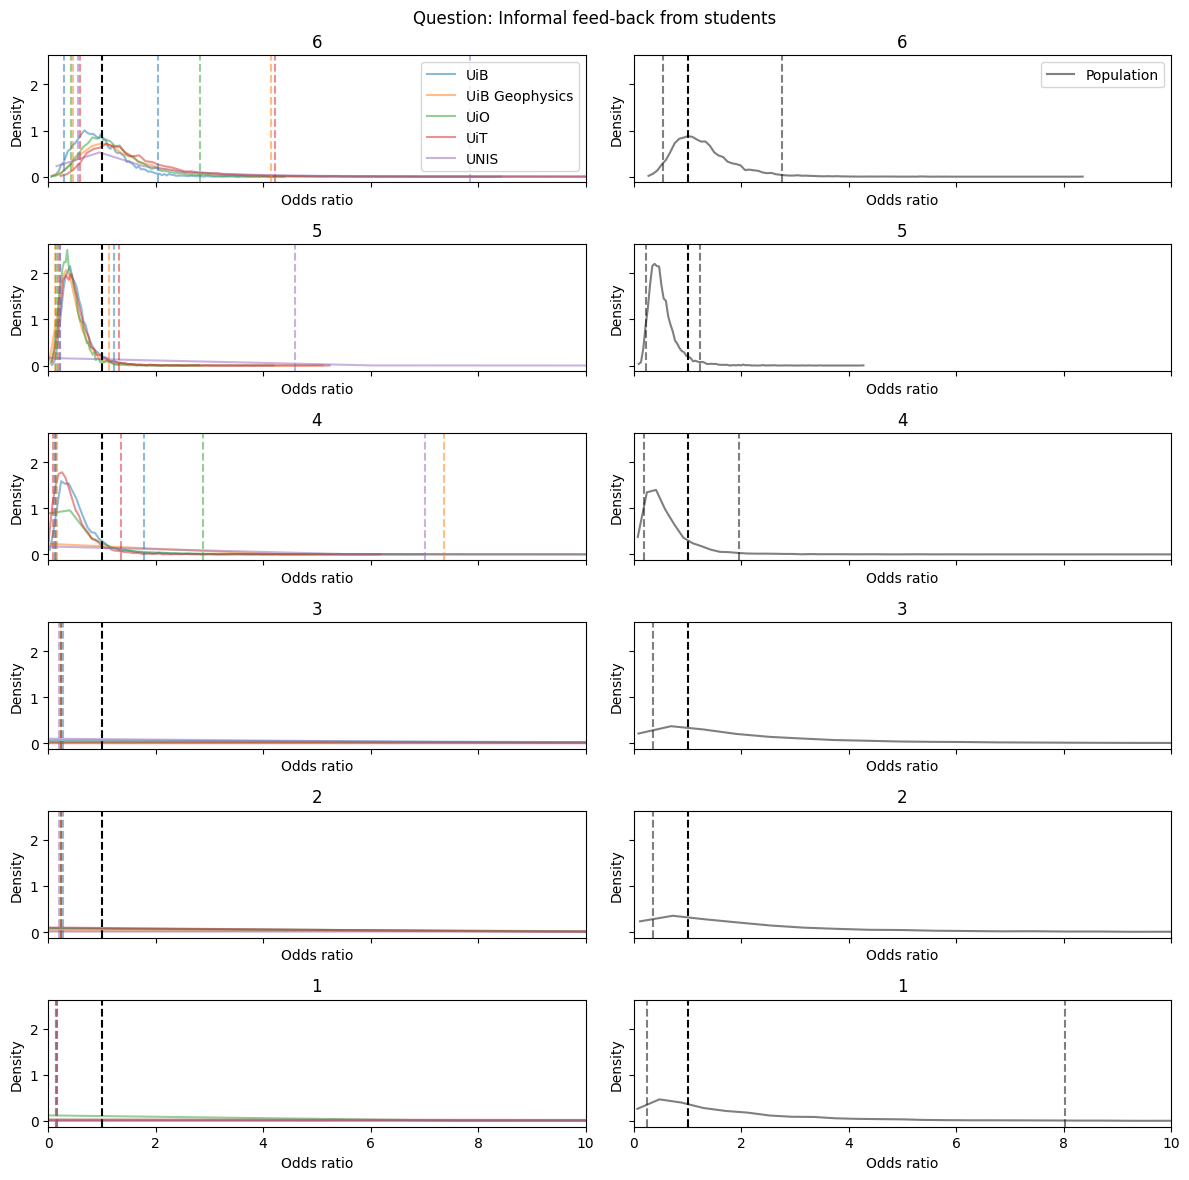

In [ ]:

def plot_set_of_slopes(samples_slopes, axs, ax_row, cutpoint_index):
    [samples_slope_population, samples_slope_uib, samples_slope_uibgeophys, samples_slope_uio, samples_slope_uit, samples_slope_unis] = samples_slopes
    # find samples for the specific cutpoint 
    samples_slope_population_counts = np.histogram(samples_slope_population[cutpoint_index, :], bins=100, density=True)
    samples_slope_uib_counts = np.histogram(samples_slope_uib[cutpoint_index, :], bins=100, density=True)
    samples_slope_uibgeophys_counts = np.histogram(samples_slope_uibgeophys[cutpoint_index, :], bins=100, density=True)
    samples_slope_uio_counts = np.histogram(samples_slope_uio[cutpoint_index, :], bins=100, density=True)
    samples_slope_uit_counts = np.histogram(samples_slope_uit[cutpoint_index, :], bins=100, density=True)
    samples_slope_unis_counts = np.histogram(samples_slope_unis[cutpoint_index, :], bins=100, density=True)

    # plot the posterior distributions for each slope for the population and each group
    axs[ax_row, 1].plot(samples_slope_population_counts[1][:-1], samples_slope_population_counts[0], alpha=0.5, label="Population", color="k")
    axs[ax_row, 0].plot(samples_slope_uib_counts[1][:-1], samples_slope_uib_counts[0], alpha=0.5, label="UiB", color="tab:blue")
    axs[ax_row, 0].plot(samples_slope_uibgeophys_counts[1][:-1], samples_slope_uibgeophys_counts[0], alpha=0.5, label="UiB Geophysics", color="tab:orange")
    axs[ax_row, 0].plot(samples_slope_uio_counts[1][:-1], samples_slope_uio_counts[0], alpha=0.5, label="UiO", color="tab:green")
    axs[ax_row, 0].plot(samples_slope_uit_counts[1][:-1], samples_slope_uit_counts[0], alpha=0.5, label="UiT", color="tab:red")
    axs[ax_row, 0].plot(samples_slope_unis_counts[1][:-1], samples_slope_unis_counts[0], alpha=0.5, label="UNIS", color="tab:purple")

    # find credible intervals for each slope for the population and each group
    credible_interval = 0.95
    CI_population = np.percentile(samples_slope_population[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_uib = np.percentile(samples_slope_uib[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_uibgeophys = np.percentile(samples_slope_uibgeophys[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_uio = np.percentile(samples_slope_uio[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_uit = np.percentile(samples_slope_uit[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_unis = np.percentile(samples_slope_unis[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    
    # plot CI as vertical lines
    axs[ax_row, 1].axvline(CI_population[0], color="k", linestyle="--", alpha=0.5)
    axs[ax_row, 1].axvline(CI_population[1], color  ="k", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_uib[0], color="tab:blue", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_uib[1], color="tab:blue", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_uibgeophys[0], color="tab:orange", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_uibgeophys[1], color="tab:orange", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_uio[0], color="tab:green", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_uio[1], color="tab:green", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_uit[0], color="tab:red", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_uit[1], color="tab:red", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_unis[0], color="tab:purple", linestyle="--", alpha=0.5)
    axs[ax_row, 0].axvline(CI_unis[1], color="tab:purple", linestyle="--", alpha=0.5)

    # if ax_row != 0:
    #     return 
    axs[ax_row, 0].set_title(f"{cutpoint_index + 1}")
    axs[ax_row, 1].set_title(f"{cutpoint_index + 1}")


def plot_binary_slopes_for_question(question, selection, exponentiate=False):

    slope_by_split_population = np.load(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_population.npy")
    slope_by_split_groups = np.load(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_groups.npy")

    slope_by_split_population = slope_by_split_population.reshape(-1, slope_by_split_population.shape[-1]) # shape: (num_cutpoints, num_samples)
    slope_by_split_groups = slope_by_split_groups.reshape(-1, slope_by_split_groups.shape[-2], slope_by_split_groups.shape[-1]) # shape: (num_cutpoints, num_groups, num_samples)
    slope_by_split_uib = slope_by_split_groups[:, 0, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_uibgeophys = slope_by_split_groups[:, 1, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_uio = slope_by_split_groups[:, 2, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_uit = slope_by_split_groups[:, 3, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_unis = slope_by_split_groups[:, 4, :] # shape: (num_cutpoints, num_samples)

    if exponentiate:
        slope_by_split_population = np.exp(slope_by_split_population)
        slope_by_split_uib = np.exp(slope_by_split_uib)
        slope_by_split_uibgeophys = np.exp(slope_by_split_uibgeophys)
        slope_by_split_uio = np.exp(slope_by_split_uio)
        slope_by_split_uit = np.exp(slope_by_split_uit)
        slope_by_split_unis = np.exp(slope_by_split_unis)


    samples_slopes = [slope_by_split_population, slope_by_split_uib, slope_by_split_uibgeophys, slope_by_split_uio, slope_by_split_uit, slope_by_split_unis]

    num_deltas = slope_by_split_population.shape[0]

    fig, axs = plt.subplots(6, 2, figsize=(12, 12), sharex=True, sharey=True)
    plot_set_of_slopes(samples_slopes, axs, num_deltas - 1, 0)
    plot_set_of_slopes(samples_slopes, axs, num_deltas - 2, 1)
    plot_set_of_slopes(samples_slopes, axs, num_deltas - 3, 2)
    plot_set_of_slopes(samples_slopes, axs, num_deltas - 4, 3)
    plot_set_of_slopes(samples_slopes, axs, num_deltas - 5, 4)
    plot_set_of_slopes(samples_slopes, axs, num_deltas - 6, 5)
    for ax in axs.flatten():
        if exponentiate: 
            ax.axvline(1, color="k", linestyle="--")
            ax.set_xlabel("Odds ratio")#\n" + r"$\log \text{odds ratio}$")
            ax.set_xlim(0, 10)
        else: 
            ax.axvline(0, color="k", linestyle="--")
            ax.set_xlabel("Slope\n" + r"$\log \text{odds ratio}$")
        
        ax.set_ylabel("Density")
        # if ax not in axs[-1, :]:
    axs[0, 0].legend()
    axs[0, 1].legend()
    fig.suptitle(f"Question: {question}")
    fig.tight_layout()

# question = "Laboratory skills"
# # question = "Fieldwork skills"
question = "Informal feed-back from students"
plot_binary_slopes_for_question(question, "educators", exponentiate=1)



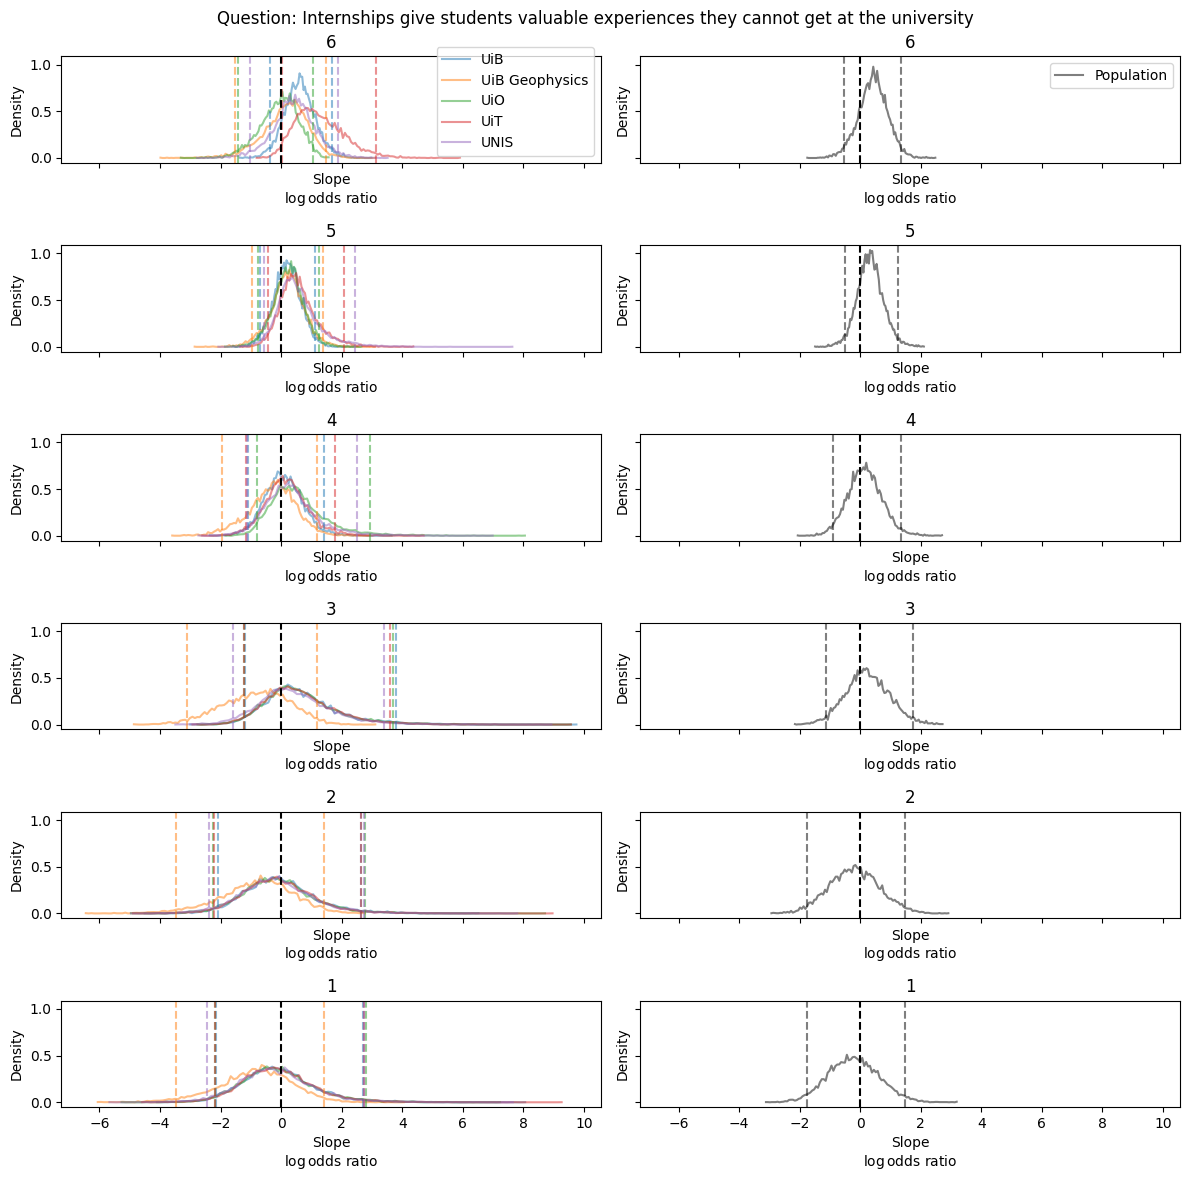

In [ ]:
question = "Internships give students valuable experiences they cannot get at the university"
selection = "educators"
plot_binary_slopes_for_question(question, selection, exponentiate=0)

dataframe['year'].value_counts() = year
0    224
Name: count, dtype: int64
dataframe['year'].value_counts() = year
1    91
Name: count, dtype: int64
<IntegerArray>
[6, 5, 6, 7, 7, 6, 6, 4, 5, 4, 2, 7, 4, 6, 7, 7, 7, 5, 6, 7, 6, 5, 6, 3, 7, 7,
 7, 7, 5, 1, 7, 6, 7, 7, 4, 7, 6, 6, 5, 6, 6, 3, 7, 4, 6, 7, 7, 6, 4, 6, 6, 7,
 5, 7, 6, 6, 2, 6, 7, 2, 7, 5, 7, 6, 7, 6, 3, 6, 6, 6, 7, 7, 3, 5, 5, 4, 7, 7,
 7, 7, 5, 5, 5, 7, 7, 6, 7, 5]
Length: 88, dtype: Int64
<IntegerArray>
[7, 5, 3, 4, 6, 7, 6, 7, 3, 5, 5, 4, 5]
Length: 13, dtype: Int64


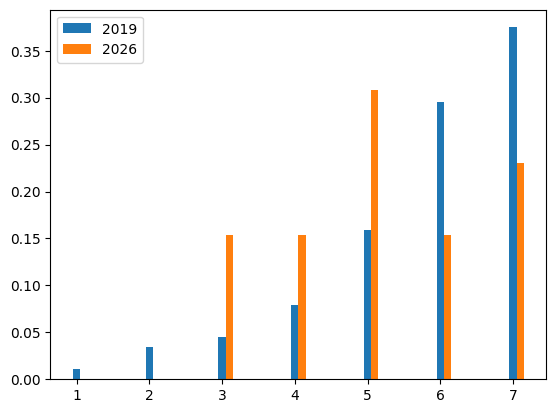

In [ ]:
selection = "students"
question = "Internships give students valuable experiences they cannot get at the university"
question = "Understanding of the subject theory"
question = "The possibilities for social contact with my fellow students are good"
df19 = df_2019_students.copy()
df26 = df_2026_students.copy()
common_q = viable_questions_students
group_mask_2019 = df19["institution"] == map_institution["uib"]
group_mask_2026 = df26["institution"] == map_institution["uib"]
df19_prepared = prepare_dataframe(df19, common_questions_dict=common_q)
df26_prepared = prepare_dataframe(df26, common_questions_dict=common_q)
repetitions_2019 = df19[group_mask_2019][question].values
repetitions_2026 = df26[group_mask_2026][question].values
counts_2019, bins = np.histogram(repetitions_2019, bins=np.arange(1,7+2), density=True)
counts_2026, bins = np.histogram(repetitions_2026, bins=np.arange(1,7+2), density=True)
fig, ax=plt.subplots()
ax.bar(bins[:-1], counts_2019, width=0.1, label="2019")
ax.bar(bins[:-1]+0.1, counts_2026, width=0.1, label="2026")
ax.legend()
print(repetitions_2019.dropna())
print(repetitions_2026.dropna())

#### make overview plot for the non POA cases

In [ ]:

def plot_CI_set_of_slopes(samples_slopes, axs, cutpoint_index):
    [samples_slope_population, samples_slope_uib, samples_slope_uibgeophys, samples_slope_uio, samples_slope_uit, samples_slope_unis] = samples_slopes

    # find credible intervals for each slope for the population and each group
    credible_interval = 0.95
    CI_population = np.percentile(samples_slope_population[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_uib = np.percentile(samples_slope_uib[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_uibgeophys = np.percentile(samples_slope_uibgeophys[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_uio = np.percentile(samples_slope_uio[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_uit = np.percentile(samples_slope_uit[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])
    CI_unis = np.percentile(samples_slope_unis[cutpoint_index, :], [(1 - credible_interval) / 2 * 100, (1 + credible_interval) / 2 * 100])

    median_population = np.percentile(samples_slope_population[cutpoint_index, :], 50)    
    median_uib = np.percentile(samples_slope_uib[cutpoint_index, :], 50)
    median_uibgeophys = np.percentile(samples_slope_uibgeophys[cutpoint_index, :], 50)
    median_uio = np.percentile(samples_slope_uio[cutpoint_index, :], 50)
    median_uit = np.percentile(samples_slope_uit[cutpoint_index, :], 50)
    median_unis = np.percentile(samples_slope_unis[cutpoint_index, :], 50)

    # plot CI as 'error bars' with midpoint being the median
    axs[0].plot(CI_population, [cutpoint_index+1]*2, marker="x")
    axs[1].plot(CI_uib, [cutpoint_index+1]*2, marker="x")
    axs[2].plot(CI_uibgeophys, [cutpoint_index+1]*2, marker="x")
    axs[3].plot(CI_uio, [cutpoint_index+1]*2, marker="x")
    axs[4].plot(CI_uit, [cutpoint_index+1]*2, marker="x")
    axs[5].plot(CI_unis, [cutpoint_index+1]*2, marker="x")
    axs[0].scatter(median_population, cutpoint_index+1)
    axs[1].scatter(median_uib, cutpoint_index+1)
    axs[2].scatter(median_uibgeophys, cutpoint_index+1)
    axs[3].scatter(median_uio, cutpoint_index+1)
    axs[4].scatter(median_uit, cutpoint_index+1)
    axs[5].scatter(median_unis, cutpoint_index+1)
    axs[0].set_title("population")
    axs[1].set_title("uib")
    axs[2].set_title("uibgeophys")
    axs[3].set_title("uio")
    axs[4].set_title("uit")
    axs[5].set_title("unis")

    
def plot_overview_nonPOA(question, selection, exponentiate=False):

    slope_by_split_population = np.load(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_population.npy")
    slope_by_split_groups = np.load(Path("..") / "binary_split_posteriors" / f"{selection}" / f"{sanitize_key(question)[:50]}_slopes_groups.npy")

    slope_by_split_population = slope_by_split_population.reshape(-1, slope_by_split_population.shape[-1]) # shape: (num_cutpoints, num_samples)
    slope_by_split_groups = slope_by_split_groups.reshape(-1, slope_by_split_groups.shape[-2], slope_by_split_groups.shape[-1]) # shape: (num_cutpoints, num_groups, num_samples)
    slope_by_split_uib = slope_by_split_groups[:, 0, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_uibgeophys = slope_by_split_groups[:, 1, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_uio = slope_by_split_groups[:, 2, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_uit = slope_by_split_groups[:, 3, :] # shape: (num_cutpoints, num_samples)
    slope_by_split_unis = slope_by_split_groups[:, 4, :] # shape: (num_cutpoints, num_samples)

    if exponentiate:
        slope_by_split_population = np.exp(slope_by_split_population)
        slope_by_split_uib = np.exp(slope_by_split_uib)
        slope_by_split_uibgeophys = np.exp(slope_by_split_uibgeophys)
        slope_by_split_uio = np.exp(slope_by_split_uio)
        slope_by_split_uit = np.exp(slope_by_split_uit)
        slope_by_split_unis = np.exp(slope_by_split_unis)


    samples_slopes = [slope_by_split_population, slope_by_split_uib, slope_by_split_uibgeophys, slope_by_split_uio, slope_by_split_uit, slope_by_split_unis]

    num_deltas = slope_by_split_population.shape[0]

    fig, axs = plt.subplots(6, 1, figsize=(6, 12), sharex=True, sharey=True)
    plot_CI_set_of_slopes(samples_slopes, axs, 0)#num_deltas - 1, 0)
    plot_CI_set_of_slopes(samples_slopes, axs, 1)#num_deltas - 2, 1)
    plot_CI_set_of_slopes(samples_slopes, axs, 2)#num_deltas - 3, 2)
    plot_CI_set_of_slopes(samples_slopes, axs, 3)#num_deltas - 4, 3)
    plot_CI_set_of_slopes(samples_slopes, axs, 4)#num_deltas - 5, 4)
    plot_CI_set_of_slopes(samples_slopes, axs, 5)#num_deltas - 6, 5)
    for ax in axs.flatten():
        if exponentiate: 
            ax.axvline(1, color="k", linestyle="--")
            ax.set_xlabel("Odds ratio")#\n" + r"$\log \text{odds ratio}$")
            # ax.set_xlim(0, 10)
        else: 
            ax.axvline(0, color="k", linestyle="--")
            ax.set_xlabel("Slope\n" + r"$\log \text{odds ratio}$")
        
        ax.set_ylabel("Cutpoint")
        # ax.set_xticks(ax.get_xticks())
        ax.set_yticks(range(1,7))
        # if ax not in axs[-1, :]:
    # axs[0].legend()
    # axs[0].legend()
    if len(question) > 50:
        # break the question into multiple lines for the title
        question = "\n".join([question[i:i+50] for i in range(0, len(question), 50)])
    fig.suptitle(f"{selection}\nQuestion: {question}")
    fig.tight_layout()
    return fig

def plot_non_POA_overviews(violated_questions, selection):
    for question, _, _ in violated_questions:
        fig = plot_overview_nonPOA(question, selection, exponentiate=1)
        if not os.path.exists(Path("..") / "figures" / "credible_interval_nonPOA_overviews" / f"{selection}"):
            os.makedirs(Path("..") / "figures" / "credible_interval_nonPOA_overviews" / f"{selection}")
        fig.savefig(Path("..") / "figures" / "credible_interval_nonPOA_overviews" / f"{selection}" / f"{sanitize_key(question)[:50]}.png")
        plt.close(fig)
plot_non_POA_overviews(violated_questions_educators, "educators")
plot_non_POA_overviews(violated_questions_students, "students")
plot_non_POA_overviews(violated_questions_admintech, "admintech")

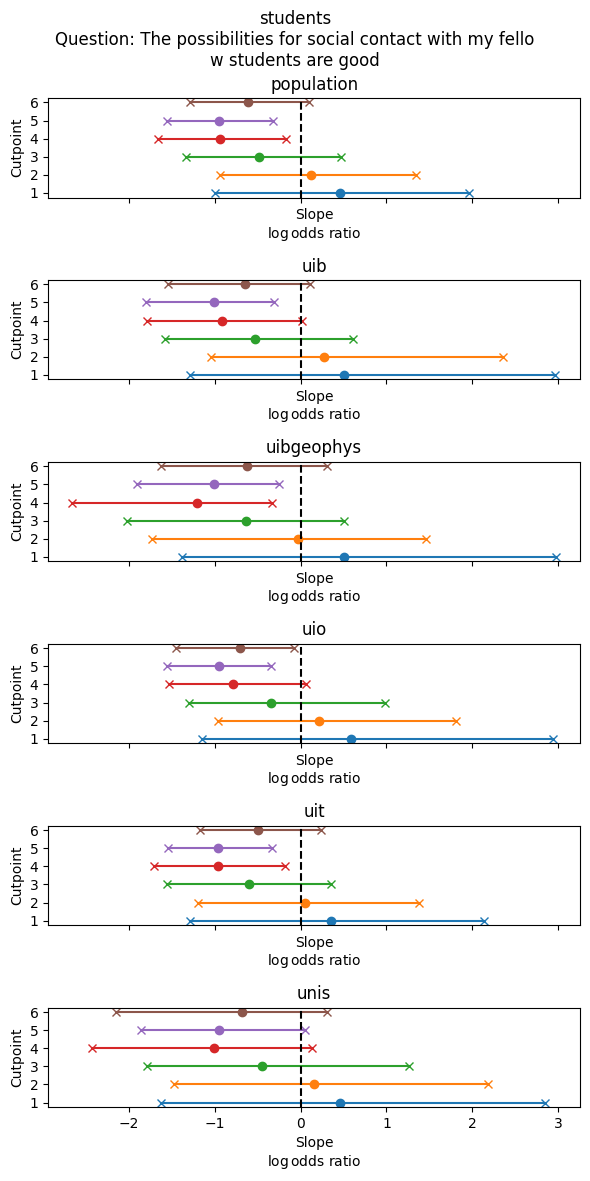

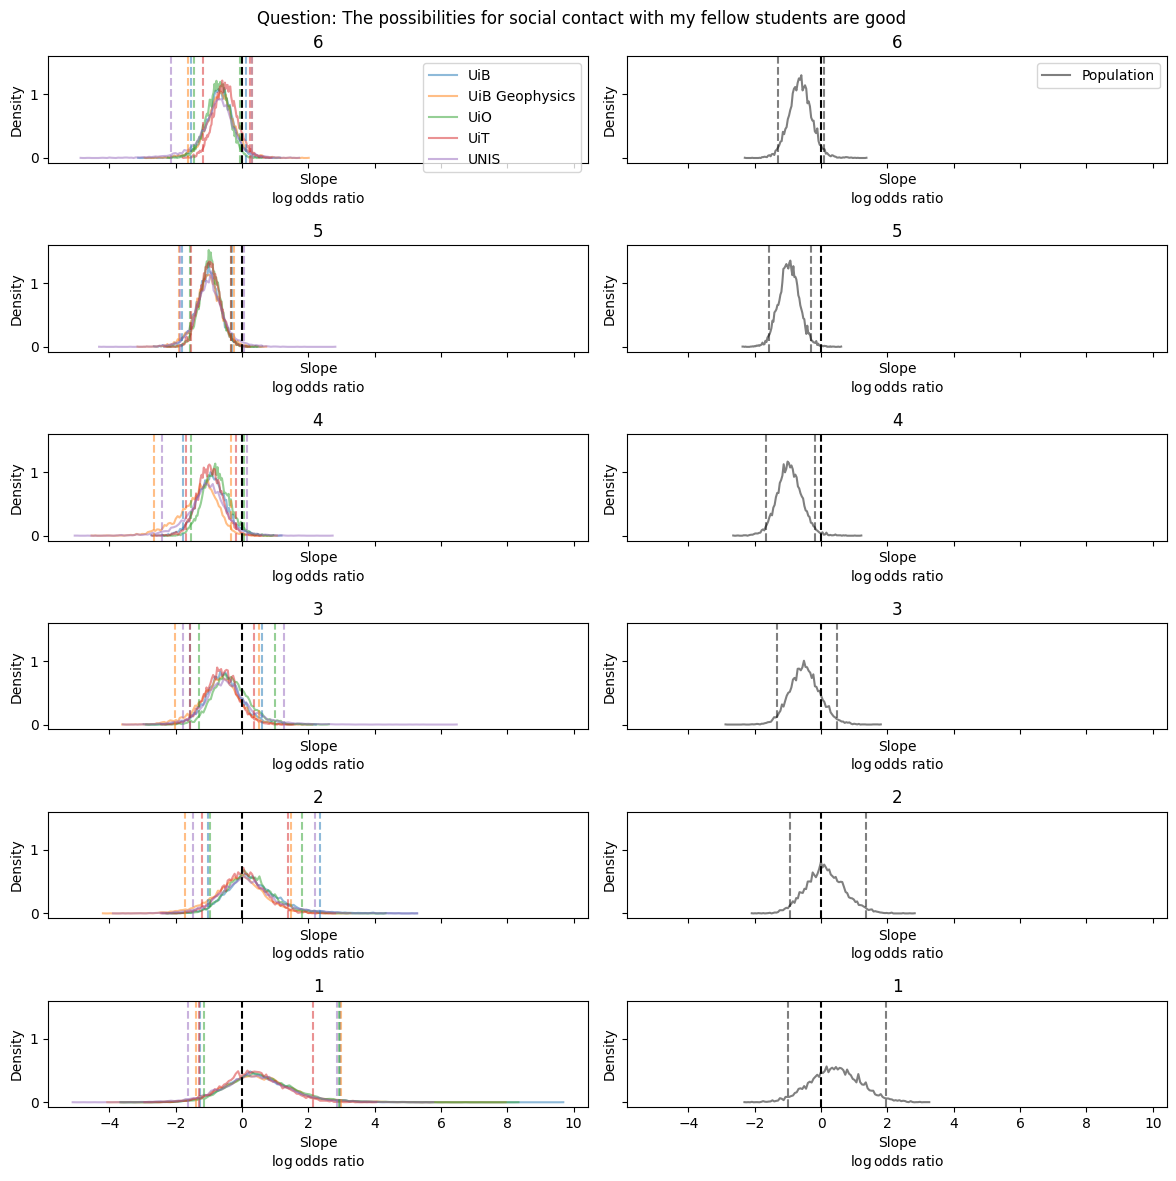

In [ ]:
selection = "students"
question = "The possibilities for social contact with my fellow students are good"
plot_overview_nonPOA(question, selection, exponentiate=0)
plot_binary_slopes_for_question(question, selection, exponentiate=0)
# plt.close("all")

#### redo overview plots

In [ ]:
# load all credible intervals for a type and group and plot them on the same plot
from plots import *
def make_overview_plot(credible_intervals_dictionary, 
                       group, subfolder, 
                       violating_questions=None,
                       superfolder=None):

    # ensure that the subfolder exists
    if superfolder is None:
        if not os.path.exists(Path("..") / "figures" / "credible_interval_overviews" / f"{subfolder}"):
            os.makedirs(Path("..") / "figures" / "credible_interval_overviews" / f"{subfolder}")
    else:
        if not os.path.exists(Path("..") / "figures" / f"{superfolder}" / "credible_interval_overviews" / f"{subfolder}"):
            os.makedirs(Path("..") / "figures" / f"{superfolder}" / "credible_interval_overviews" / f"{subfolder}")
    num_questions = len(credible_intervals_dictionary[group])
    # print(f"{credible_intervals_dictionary[group].keys() = }")
    sorted_dict = dict(sorted(credible_intervals_dictionary[group].items(), key=lambda item: item[0][0]))  # sort by the first character of the question key
    sorted_dict = dict(credible_intervals_dictionary[group].items())
    fig, ax = plt.subplots(figsize=(12,num_questions//3 + 4))
    for idx, (cred_int, median) in enumerate(sorted_dict.values()):  # sort by the first character of the question key

        # look up the question in the violating_questions set
        # print(f"{list(sorted_dict.keys())[idx] = }")
        if violating_questions and list(sorted_dict.keys())[idx] in violating_questions:
            ax.plot(cred_int, [idx, idx], marker="|", c="r")  # red for violating questions
            ax.scatter(median, idx, c="r", marker="o")
            continue

        ax.plot(cred_int, [idx, idx], marker="|", c="k")
        ax.scatter(median, idx, c="k", marker="o")

    # place reference line
    ax.vlines(1, -1, num_questions, color="k")
    # ax.set_xlim(-0.5, 5)
    
    # set the questions as y-ticks
    labels_list = []
    for q in sorted_dict.keys():
        if len(q) > 50:
            labels_list.append(q[:47] + "...")
        else:
            labels_list.append(q[:])
    ax.set_yticks(range(num_questions), labels=labels_list)

    ax.set_xlabel("Odds ratio", fontsize=fig_axis_fs)#\n" + r"$\mathbb{E}[X_{2026}] - \mathbb{E}[X_{18/19}]$", fontsize=fig_axis_fs)
    ax.set_ylabel("Question", fontsize=fig_axis_fs)
    fig.suptitle(f"95% credible intervals\n{subfolder}\n{group}\n" + 
                 "Questions violaing POA are colored in red\n", fontsize=fig_title_fs+2)
    fig.tight_layout()
    if superfolder is None:
        fig.savefig(Path("..") / "figures" / "credible_interval_overviews" / f"{subfolder}" / f"{group}")
    else:
        fig.savefig(Path("..") / "figures" / f"{superfolder}" / "credible_interval_overviews" / f"{subfolder}" / f"{group}")
    plt.close()

for group in credible_intervals["educators"].keys():
    make_overview_plot(credible_intervals["educators"], group, subfolder="Educators",
                       violating_questions={q for q, g, c in violated_questions_educators})# if g == group})
for group in credible_intervals["students"].keys():
    make_overview_plot(credible_intervals["students"], group, subfolder="Students",
                       violating_questions={q for q, g, c in violated_questions_students})# if g == group})
for group in credible_intervals["admintech"].keys():
    make_overview_plot(credible_intervals["admintech"], group, subfolder="AdminTech",
                       violating_questions={q for q, g, c in violated_questions_admintech})# if g == group})
    

### Highlighting the significant changes


#### filtering the signifcant results out

In [ ]:
def is_significant(stats):
    credible_interval, median = stats
    lower, upper = credible_interval
    if 1 < lower or upper < 1:
        return median
    return 0


def extract_significant_results_from_CI(credible_intervals):
    """extract the significant results from the credible_intervals dictionary
    respecting the hierarchy
    selection -> question -> group -> cutpoint: (credible_interval, median)
    """
    violated_questions = {
        "educators": violated_questions_educators, 
        "students": violated_questions_students, 
        "admintech": violated_questions_admintech, 
    }
    significant_results = []
    for selection, selection_dictionary in credible_intervals.items():
        for group, group_dictionary in selection_dictionary.items():
            for question, stats in group_dictionary.items():
                
                # ignore result violating POA for now
                # print(f"{question = }")
                # print(f"{[q[0] for q in violated_questions[selection]] = }")
                if question in [q[0] for q in violated_questions[selection]]:
                    # print(question)
                    continue

                # test significance
                significant = is_significant(stats)
                if significant:
                    significant_results.append((selection, question, "all", group, significant))
    return significant_results

def extract_significant_results_from_CI_nonPOA(credible_intervals_nonPOA):
    """extract the significant results from the credible_intervals dictionary
    respecting the hierarchy
    selection -> question -> group -> cutpoint: (credible_interval, median)

    """
    significant_results = []
    for selection, selection_dictionary in credible_intervals_nonPOA.items():
        for question, question_dictionary in selection_dictionary.items():
            for group, group_dictionary in question_dictionary.items():
                for cutpoint_index, stats in enumerate(group_dictionary):
                    significant = is_significant(stats)
                    if significant:
                        significant_results.append((selection, question, cutpoint_index + 1, group, significant))
    return significant_results


def merge_significant_results(significant_results, significant_results_nonPOA):
    """merge the significant results from the two lists into one list
    
    selection, question, cutpoint, group, median
    """
    merged = {}
    for selection, question, cutpoint, group, median in significant_results:
        # create the hierarchy if it doesn't exist
        if selection not in merged:
            merged[selection] = {}
        if question not in merged[selection]:
            merged[selection][question] = {}
        if cutpoint not in merged[selection][question]:
            merged[selection][question][cutpoint] = {}
        
        merged[selection][question][cutpoint][group] = median
    for selection, question, cutpoint, group, median in significant_results_nonPOA:
        # create the hierarchy if it doesn't exist
        if selection not in merged:
            merged[selection] = {}
        if question not in merged[selection]:
            merged[selection][question] = {}
        if cutpoint not in merged[selection][question]:
            merged[selection][question][cutpoint] = {}

        merged[selection][question][cutpoint][group] = median
    return merged

significant_results = extract_significant_results_from_CI(credible_intervals)
significant_results_nonPOA = extract_significant_results_from_CI_nonPOA(credible_intervals_nonPOA)
merged_significant_results = merge_significant_results(significant_results, significant_results_nonPOA)

# print(f"Significant results: {significant_results}")
# print(f"Significant results (non-POA): {significant_results_nonPOA}")
# print(f"Merged significant results: {merged_significant_results}")
for selection, selection_dictionary in merged_significant_results.items():
    for question, question_dictionary in selection_dictionary.items():
        for cutpoint, cutpoint_dictionary in question_dictionary.items():
            for group, median in cutpoint_dictionary.items():
                print(f"Selection: {selection}, Question: {question}, Cutpoint: {cutpoint}, Group: {group}, Median: {median}")

Selection: educators, Question: Other geoscience departments at non-Norwegian universities, Cutpoint: all, Group: population, Median: 0.41105489024865194
Selection: educators, Question: Other geoscience departments at non-Norwegian universities, Cutpoint: all, Group: uibgeophys, Median: 0.3892631452470751
Selection: educators, Question: Other geoscience departments at non-Norwegian universities, Cutpoint: all, Group: uio, Median: 0.3621465742716691
Selection: educators, Question: Other geoscience departments at non-Norwegian universities, Cutpoint: all, Group: uit, Median: 0.396830289115361
Selection: educators, Question: Research institutions, Cutpoint: all, Group: population, Median: 0.46958984459921593
Selection: educators, Question: Research institutions, Cutpoint: all, Group: uib, Median: 0.4557987304536427
Selection: educators, Question: Research institutions, Cutpoint: all, Group: uio, Median: 0.44261619408127956
Selection: educators, Question: Research institutions, Cutpoint: a

#### Generate some text highlighting the significant results

In [ ]:
def generate_signifcant_tex():
    path = "significant highlights.txt"
    with open(path, mode="w") as doc:
        viable_questions_dict = {
            "educators": viable_questions_educators, 
            "students": viable_questions_students, 
            "admintech": viable_questions_admintech, 
        }
        n = 0
        print(f"{list(viable_questions_students.keys())}")
        # doc.write("\\section{Significant Highlights}\n")
        for selection, selection_dictionary in merged_significant_results.items():
            doc.write(r"\subsection{" + f"{selection}" + r"}" + "\n")

            # stick to the order which is present in the viable questions
            for question in viable_questions_dict[selection].keys():
                # print(f"{list(selection_dictionary.keys()) = }")
                print(f"{question = }")
                if question not in list(selection_dictionary.keys()):
                    print("not found")
                    continue

                question_dictionary = selection_dictionary[question]
            # for question, question_dictionary in selection_dictionary.items():

                doc.write(r"\subsubsection{" + f"{question}" + r"}" + "\n")
                for cutpoint, cutpoint_dictionary in question_dictionary.items():
                    for group, median in cutpoint_dictionary.items():
                        doc.write("There is evidence supporting " + 
                                f"an odds ratio of ")
                        if median < 1.0:
                            doc.write(f"1/{1/median:.1f} ")
                        else:
                            doc.write(f"{median:.1f} ")
                        if group == "population":
                            doc.write("across all universities ")
                        else:    
                            doc.write(f"for the participants at {group} ")


                        if cutpoint == "all":
                            doc.write(f"across all categories. ")

                        else:
                            doc.write(f"for the odds of responding {cutpoint+1} ")
                            if cutpoint !=6:
                                doc.write("or above ")

                            doc.write(f"versus ")
                            
                            if cutpoint != 1:
                                doc.write(f"less than or equal to ")
                            doc.write(f"{cutpoint}")

                        doc.write("\n\n\n")
                        n += 1
            doc.write("\\clearpage")

    print(f"{n = }")


#### Make overview plot for the signifcant results

unfortunately, the current overview plot function is not easy to reuse, since the signifant results object is formatted differently

In [ ]:

superfolder = "significant"
# os.mkdir(f"..\\figures\\{superfolder}")
# load all credible intervals for a type and group and plot them on the same plot
from plots import *
def make_signifcant_overview_plot(significant_results, 
                       target_group, subfolder):


    fig, ax = plt.subplots(figsize=(12, 10))
    idx = 0
    plotted_questions = []
    for (selection, question, cutpoints, group, median) in significant_results:  # sort by the first character of the question key

        if group != target_group:
            continue

        if selection != subfolder:
            continue

        # look up the question in the credible intervals dictionary to get the
        # credible interval
        cred_int, _median_ = credible_intervals[selection][group][question]

        if median != _median_:
            print(f"Median mismatch for {selection}, {question}, {group}: {median} != {_median_}")

        ax.plot(cred_int, [idx, idx], marker="|", c="k")
        ax.scatter(median, idx, c="k", marker="o")

        plotted_questions.append(question)
        idx += 1
    # # place reference line
    ax.axvline(1, color="k")
    # # ax.set_xlim(-0.5, 5)
    
    # # set the questions as y-ticks
    labels_list = []
    for q in plotted_questions:
        if len(q) > 50:
            labels_list.append(q[:47] + "...")
        else:
            labels_list.append(q[:])
    ax.set_yticks(range(idx), labels=labels_list)

    ax.set_xlabel("Odds ratio", fontsize=fig_axis_fs)#\n" + r"$\mathbb{E}[X_{2026}] - \mathbb{E}[X_{18/19}]$", fontsize=fig_axis_fs)
    ax.set_ylabel("Question", fontsize=fig_axis_fs)
    fig.suptitle(f"95% credible intervals\n\n{subfolder}\n{target_group}\n" + 
                 "Only signifcant results, with proportinal odds assumption", fontsize=fig_title_fs+2)
    fig.tight_layout()
    # make the directory if it doesn't exist
    if not os.path.exists(Path("..") / "figures" / "significant" / "credible_interval_overviews" / f"{subfolder}"):
        os.makedirs(Path("..") / "figures" / "significant" / "credible_interval_overviews" / f"{subfolder}")
    fig.savefig(Path("..") / "figures" / "significant" / "credible_interval_overviews" / f"{subfolder}" / f"{target_group}")
    plt.close()

print(f"{significant_results}")
for selection in ["educators", "students", "admintech"]:
    for group in ["population", "uib", "uibgeophys", "uio", "uit", "unis"]:
        make_signifcant_overview_plot(significant_results, group, 
                                      subfolder=selection)

[('educators', 'Other geoscience departments at non-Norwegian universities', 'all', 'population', np.float64(0.41105489024865194)), ('educators', 'Research institutions', 'all', 'population', np.float64(0.46958984459921593)), ('educators', 'Academic staff', 'all', 'population', np.float64(2.4426366194232343)), ('educators', 'Administrative/technical staff at the department', 'all', 'population', np.float64(2.69269396690611)), ('educators', 'The academic content', 'all', 'population', np.float64(2.1570709966354125)), ('educators', 'I am confident in my abilities as a teacher', 'all', 'population', np.float64(0.46659134417989556)), ('educators', 'Students.2', 'all', 'population', np.float64(2.467574590672354)), ('educators', 'The geoscience department at UiB', 'all', 'uib', np.float64(4.046232149740433)), ('educators', 'Research institutions', 'all', 'uib', np.float64(0.4557987304536427)), ('educators', 'Academic staff', 'all', 'uib', np.float64(3.0833033720952465)), ('educators', 'Admin

#### Overview plot for all the NonPOA significant results

In [ ]:

superfolder = "significant"
# os.mkdir(f"..\\figures\\{superfolder}")
# load all credible intervals for a type and group and plot them on the same plot
from plots import *
def make_signifcant_nonPOA_overview_plot(significant_results_nonPOA, 
                       target_group, subfolder):


    fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True, sharey=True)
    idx = 0
    # we must find the order of the questions first, otherwise the y-ticks will be wrong, so we will first loop through the significant results to find the order of the questions, then we will loop through again to plot them
    questions_order = []
    for (selection, question, cutpoint, group, median) in significant_results_nonPOA:  # sort by the first character of the question key
        if group != target_group:
            continue

        if selection != subfolder:
            continue

        if question not in questions_order:
            questions_order.append(question)
    # plot the question
    for (selection, question, cutpoint, group, median) in significant_results_nonPOA:  # sort by the first character of the question key
        # cutpoint 1 should be placed at axs[5] and cutpoint 6 should be placed at axs[0], so we need to reverse the order of the axs array
        

        if group != target_group:
            continue

        if selection != subfolder:
            continue

        ax = axs[len(axs) - cutpoint]

        # look up the question in the nonPOA credible intervals dictionary to get the
        # credible interval
        cred_int, _median_ = credible_intervals_nonPOA[selection][question][group][cutpoint-1]

        if median != _median_:
            print(f"Median from significant results ({median}) does not match median from credible intervals ({_median_}) for question {question}, cutpoint {cutpoint}, group {group}, selection {selection}")

        ypos = questions_order.index(question)
        ax.plot(cred_int, [ypos, ypos], marker="|", c="k")
        ax.scatter(median, ypos, c="k", marker="o")

    # # place reference line
    for ax in axs:
        ax.axvline(1, color="k")
        ax.set_title(f"Cutpoint {len(axs) - (list(axs).index(ax))}")

    # # ax.set_xlim(-0.5, 5)
    
        # # # set the questions as y-ticks
        labels_list = []
        for q in questions_order:
            if len(q) > 50:
                labels_list.append(q[:47] + "...")
            else:
                labels_list.append(q[:])
        ax.set_yticks(range(len(questions_order)), labels=labels_list)

    fig.supxlabel("Odds ratio", fontsize=fig_axis_fs)#\n" + r"$\mathbb{E}[X_{2026}] - \mathbb{E}[X_{18/19}]$", fontsize=fig_axis_fs)
    fig.supylabel("Question", fontsize=fig_axis_fs)
    fig.suptitle(f"95% credible intervals\n\n{subfolder}\n{target_group}\n" + 
                 "Only signifcant results, no proportional odds assumption", fontsize=fig_title_fs+2)
    fig.tight_layout()
    # make the directory if it doesn't exist
    if not os.path.exists(Path("..") / "figures" / "significant" / "credible_interval_nonPOA_overviews" / f"{subfolder}"):
        os.makedirs(Path("..") / "figures" / "significant" / "credible_interval_nonPOA_overviews" / f"{subfolder}")
    fig.savefig(Path("..") / "figures" / "significant" / "credible_interval_nonPOA_overviews" / f"{subfolder}" / f"{target_group}")
    plt.close()
print(f"{credible_intervals_nonPOA = }")
print(f"{significant_results_nonPOA}")
for selection in ["educators", "students", "admintech"]:
    for group in ["population", "uib", "uibgeophys", "uio", "uit", "unis"]:
        make_signifcant_nonPOA_overview_plot(significant_results_nonPOA, group, 
                                      subfolder=selection)

credible_intervals_nonPOA = {'educators': {'Students': {'population': [(array([0.47106443, 5.23159881]), np.float64(1.4395424781590114)), (array([0.57777626, 4.89586715]), np.float64(1.57796456580457)), (array([0.36446389, 1.79456137]), np.float64(0.7704629564350167)), (array([0.9321344 , 4.52561643]), np.float64(2.004265861560758)), (array([1.01043917, 7.15933392]), np.float64(2.8858491013792684)), (array([ 1.46703446, 15.17614792]), np.float64(4.803003784326702))], 'uib': [(array([0.30953326, 4.68468774]), np.float64(1.2015981370472248)), (array([0.41589892, 4.21186629]), np.float64(1.3156812817536672)), (array([0.25695421, 1.4260484 ]), np.float64(0.6469222441424363)), (array([0.88051173, 4.61534667]), np.float64(1.9993843526551909)), (array([ 1.45741702, 11.1496737 ]), np.float64(3.7396490999097134)), (array([ 1.93224907, 25.30409584]), np.float64(6.510390184208918))], 'uibgeophys': [(array([ 0.35952451, 14.19789186]), np.float64(1.5388417470376567)), (array([0.37047291, 6.41119601